**Numerical Comparison of KKL Observer Learning Methods**
    
This notebook provides a framework to train and numerically compare four different deep learning-based methods for designing Kazantzis-Kravaris-Luenberger (KKL) observers for autonomous nonlinear systems.
1. **Niazi et al. (2025):** Sequential learning, PINN (SPINN)
2. **Buisson-Fenet et al (2023)** Unsupervised Autoencoder (AE), observer gain tuning.
3. **Miao & Gatsis (2023):** Neural ODE (NODE), learns observer eigenvalues.
3. **Peralez & Nadri (2024):** Deep model-free (DMF), asymptotic version

**Benchmark System:**
1. Reverse Duffing Oscillator

**Evaluation Criteria:**
-   **Generalization:** RMSE & SMAPE on unseen data
-   **Computational Cost:** Training time

In [ ]:
import torch
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import DataLoader, TensorDataset
import numpy as np
import matplotlib.pyplot as plt
import pandas as pd
from scipy.integrate import solve_ivp

# Install torchdiffeq if not already installed
try:
    import torchdiffeq
    print("torchdiffeq is already installed.")
except ImportError:
    print("torchdiffeq not found, installing...")
    !pip install torchdiffeq
    print("torchdiffeq installed.")

from torchdiffeq import odeint # For continuous-time simulation
from torchdiffeq import odeint_adjoint # If using adjoint method for faster/lower-memory backprop
import time
from tqdm.notebook import tqdm
import os
import torch.autograd.functional # For Jacobian-vector product (jvp)

# Set device - Check for TPU first, then GPU, then default to CPU
if 'COLAB_TPU_ADDR' in os.environ:
    # If in a Colab TPU runtime, import torch_xla and set device
    print("TPU runtime detected.")
    try:
        import torch_xla.core.xla_model as xm
        device = xm.xla_device()
        print(f"Using device: {device} (TPU)")
    except ImportError:
        print("torch_xla not found. Please ensure you are in a TPU runtime and install torch_xla.")
        device = torch.device("cpu")
        print(f"Using device: {device} (CPU fallback)")
else:
    # Check for GPU if not in a TPU runtime
    device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
    print(f"Using device: {device} ({'GPU' if device.type == 'cuda' else 'CPU'})")

torchdiffeq is already installed.
Using device: cuda (GPU)


## 1. System Definitions

First, we define the dynamics and output functions for our continuous-time benchmark systems. We also include an RK4 step function for the discrete-time methods.

In [ ]:
class ReverseDuffing:
    def __init__(self):
        self.n_x = 2
        self.n_y = 1
        self.name = "ReverseDuffing"
        self.x_space_bounds = [(-1, 1), (-1, 1)]

    def f(self, t, x):
        x1, x2 = x
        dx1_dt = x2**3
        dx2_dt = -x1
        return [dx1_dt, dx2_dt]

    def h(self, x):
        return x[..., 0:1]  # y = x1

    def rk4_step(self, x, dt):
        k1 = torch.tensor(self.f(0, x.cpu().numpy()), dtype=x.dtype, device=x.device)
        k2 = torch.tensor(self.f(0, (x + 0.5 * dt * k1).cpu().numpy()), dtype=x.dtype, device=x.device)
        k3 = torch.tensor(self.f(0, (x + 0.5 * dt * k2).cpu().numpy()), dtype=x.dtype, device=x.device)
        k4 = torch.tensor(self.f(0, (x + dt * k3).cpu().numpy()), dtype=x.dtype, device=x.device)
        return x + (dt / 6.0) * (k1 + 2 * k2 + 2 * k3 + k4)


class SimplePendulum:
    def __init__(self, g=9.8, L=1):
        self.n_x = 2
        self.n_y = 1
        self.g = g
        self.L = L
        self.name = "Pendulum"
        self.x_space_bounds = [(-1.5, 1.5), (-4, 4)]

    def f(self, t, x):
        x1, x2 = x
        dx1_dt = x2
        dx2_dt = -self.g/self.L * np.sin(x1)
        return [dx1_dt, dx2_dt]

    def h(self, x):
        # x is (batch_size, n_x) or (n_x,)
        return x[..., 0:1]  # y = x1

    def rk4_step(self, x, dt):
        # x is torch tensor
        k1 = torch.tensor(self.f(0, x.cpu().numpy()), dtype=x.dtype, device=x.device)
        k2 = torch.tensor(self.f(0, (x + 0.5 * dt * k1).cpu().numpy()), dtype=x.dtype, device=x.device)
        k3 = torch.tensor(self.f(0, (x + 0.5 * dt * k2).cpu().numpy()), dtype=x.dtype, device=x.device)
        k4 = torch.tensor(self.f(0, (x + dt * k3).cpu().numpy()), dtype=x.dtype, device=x.device)
        return x + (dt / 6.0) * (k1 + 2 * k2 + 2 * k3 + k4)


class LotkaVolterra:
    def __init__(self, a=2/3, b=4/3, c=1, d=1):
        self.n_x = 2
        self.n_y = 1
        self.a = a
        self.b = b
        self.c = c
        self.d = d
        self.name = "Lotka-Volterra"
        self.x_space_bounds = [(0, 1), (0, 1)]

    def f(self, t, x):
        x1, x2 = x
        dx1_dt = self.a*x1 - self.b*x1*x2
        dx2_dt = self.d*x1*x2 - self.c*x2
        return [dx1_dt, dx2_dt]

    def h(self, x):
        # x is (batch_size, n_x) or (n_x,)
        return x[..., 0:1]  # y = x1

    def rk4_step(self, x, dt):
        # x is torch tensor
        k1 = torch.tensor(self.f(0, x.cpu().numpy()), dtype=x.dtype, device=x.device)
        k2 = torch.tensor(self.f(0, (x + 0.5 * dt * k1).cpu().numpy()), dtype=x.dtype, device=x.device)
        k3 = torch.tensor(self.f(0, (x + 0.5 * dt * k2).cpu().numpy()), dtype=x.dtype, device=x.device)
        k4 = torch.tensor(self.f(0, (x + dt * k3).cpu().numpy()), dtype=x.dtype, device=x.device)
        return x + (dt / 6.0) * (k1 + 2 * k2 + 2 * k3 + k4)



# sample_x0 accepts state space bounds directly
def sample_x0(bounds, n_samples):
    samples = []
    # Ensure bounds are in (min, max) format
    if isinstance(bounds, list) and isinstance(bounds[0], tuple):
        for (low, high) in bounds:
            samples.append(np.random.uniform(low, high, n_samples))
    else: # Fallback for simple (min, max) array
        low, high = bounds
        samples.append(np.random.uniform(low, high, (n_samples, len(low))))
        return samples[0]

    return np.stack(samples, axis=-1).squeeze()

# sample_x_points samples uniformly from a hyperrectangle defined by min_vals and max_vals
def sample_x_points(min_vals: torch.Tensor, max_vals: torch.Tensor, n_samples: int) -> torch.Tensor:
    n_dim = min_vals.shape[0]
    # Generate random numbers between 0 and 1
    rand_samples = torch.rand(n_samples, n_dim, device=min_vals.device)
    # Scale to desired range
    return min_vals + rand_samples * (max_vals - min_vals)

## 2. Helper Functions & Common Components

Generic MLP class and other functions to create observer matrices.

In [ ]:
class MLP(nn.Module):
    def __init__(self, input_dim, output_dim, hidden_dims, activation=nn.ReLU):
        super().__init__()
        layers = []
        dims = [input_dim] + hidden_dims + [output_dim]
        for i in range(len(dims) - 2):
            layers.append(nn.Linear(dims[i], dims[i+1]))
            # Check if activation is a class or an instance
            if isinstance(activation, nn.Module): # If it's already an instance
                 layers.append(activation)
            else: # Assume it's a class and instantiate it
                 layers.append(activation())
        layers.append(nn.Linear(dims[-2], dims[-1]))
        self.net = nn.Sequential(*layers)

    def forward(self, x):
        return self.net(x)


def create_observer_matrices(n_z, n_y, system_name, strategy='diagonal', base_eig=-0.5):
    # Creates a stable A matrix and a B matrix such that (A,B) controllable.
    # Strategy can be 'diagonal' or 'random_stable'.

    A = None
    B = None

    if strategy == 'random_stable':
        print(f"Using random stable A and ones B for system {system_name} with n_z={n_z}, n_y={n_y}.")
        # Generate a random matrix and make it stable
        # A common trick: A = -(rand_matrix + rand_matrix.T) or similar to ensure negative real part eigenvalues
        rand_matrix = torch.randn(n_z, n_z, dtype=torch.float32, device=device)
        A = -torch.matmul(rand_matrix, rand_matrix.T) # This generates a negative definite matrix, ensuring stable eigenvalues
        # Alternatively, generate random A and shift eigenvalues:
        # A = torch.randn(n_z, n_z, dtype=torch.float32, device=device)
        # eigvals, _ = torch.linalg.eig(A) # Use torch.linalg.eig for complex eigenvalues
        # A = A - (torch.max(eigvals.real) + 1e-2) * torch.eye(n_z, device=device) # Shift max real part below zero


        # Create a B matrix (e.g., ones, to ensure controllability with diag A)
        B = torch.ones((n_z, n_y)).to(device)

    elif strategy == 'diagonal': # Use diagonal A if strategy is 'diagonal'
         print(f"Using diagonal A and ones B for system {system_name} with n_z={n_z}, n_y={n_y}.")
         eigs = torch.linspace(base_eig, base_eig * 4, n_z)
         A = torch.diag(eigs).to(device)
         # Create a B matrix (e.g., ones, to ensure controllability with diag A)
         B = torch.ones((n_z, n_y)).to(device)

    else: # Default to diagonal if an unknown strategy is provided
        print(f"Unknown matrix strategy '{strategy}' for system {system_name}. Defaulting to diagonal A and ones B.")
        eigs = torch.linspace(base_eig, base_eig * 4, n_z)
        A = torch.diag(eigs).to(device)
        B = torch.ones((n_z, n_y)).to(device)

    return A, B

def generate_trajectory_data(system, x0, t_span, dt):
    # Generates a single continuous trajectory.
    t_eval = np.arange(t_span[0], t_span[1] + dt, dt)
    sol = solve_ivp(system.f, t_span, x0, t_eval=t_eval, method='RK45')

    t_torch = torch.tensor(sol.t, dtype=torch.float32).to(device)
    x_torch = torch.tensor(sol.y.T, dtype=torch.float32).to(device)
    y_torch = system.h(x_torch)

    return t_torch, x_torch, y_torch

In [ ]:
def KKL_observer_data(A_obs_np, B_obs_np, y_data_np, t_eval_np, ic_z_np):
    # Simulates the observer z dynamics given system outputs y(t)
    n_ic, n_steps_plus_1, n_y = y_data_np.shape
    n_z, _ = B_obs_np.shape

    A_obs_torch = torch.tensor(A_obs_np, dtype=torch.float32).to(device)
    B_obs_torch = torch.tensor(B_obs_np, dtype=torch.float32).to(device)
    t_eval_torch = torch.tensor(t_eval_np, dtype=torch.float32).to(device) # Use provided t_eval_np

    z_data = np.zeros((n_ic, n_steps_plus_1, n_z), dtype=np.float32)


    for i in range(n_ic):
        z0_i_torch = torch.tensor(ic_z_np[i], dtype=torch.float32).to(device)
        y_traj_i_torch = torch.tensor(y_data_np[i], dtype=torch.float32).to(device)

        # Define observer dynamics for odeint
        def observer_dynamics(t, z):
             # Need to interpolate y_traj_i_torch at time t
             # y_traj_i_torch shape is (n_steps + 1, n_y)
             # t_eval_torch shape is (n_steps + 1,)

             # Convert t to a scalar for numpy interpolation
             t_scalar = t.item() if t.ndim > 0 else t.item()

             # Interpolate each output dimension separately
             y_t_list = []
             for j in range(n_y):
                 y_j_interp = np.interp(t_scalar, t_eval_torch.cpu().numpy(), y_traj_i_torch[:, j].cpu().numpy())
                 y_t_list.append(y_j_interp)

             y_t_torch = torch.tensor(y_t_list, dtype=torch.float32).to(device)


             # Ensure y_t_torch has shape (n_y,) for matrix multiplication
             if y_t_torch.ndim == 0:
                  y_t_torch = y_t_torch.unsqueeze(0) # Add dimension if scalar
             elif y_t_torch.ndim > 1 and y_t_torch.shape[0] == 1:
                  y_t_torch = y_t_torch.squeeze(0) # Remove batch dim if present

             return A_obs_torch @ z + B_obs_torch @ y_t_torch

        # Simulate using odeint
        with torch.no_grad(): # Simulation doesn't need gradients
             z_traj_torch = odeint(
                 observer_dynamics,
                 z0_i_torch,
                 t_eval_torch, # Use the provided t_eval_torch
                 method='rk4' # Use rk4 for simulation
             ).to(device)

        z_data[i, :, :] = z_traj_torch.cpu().numpy()

    return z_data

In [ ]:
# Data standardization / normalization

def scale_minmax(data, data_min, data_max):
    """Applies Min-Max scaling to [-1, 1]."""
    data_range = data_max - data_min
    data_range[data_range == 0] = 1e-8 # Avoid division by zero
    return 2.0 * (data - data_min) / data_range - 1.0

def unscale_minmax(scaled_data, data_min, data_max):
    """Applies inverse Min-Max scaling from [-1, 1]."""
    data_range = data_max - data_min
    data_range[data_range == 0] = 1e-8
    return (scaled_data + 1.0) / 2.0 * data_range + data_min

## 3. Method 1: SPINN (Our method)

- **Trajectory Data:** Simulates `(x_traj, z_traj)` trajectories, truncates `z_traj`'s transient
- **Sample Points:** Sample points `x_points` in state space `X`
-   **Phase 1 (Train T):** `Loss = MSE(z_traj, T(x_traj)) + nu * MSE(PDE_residual(x_points))`
-   **Phase 2 (Train T_inv):** `Loss = MSE(x_points, T_inv(T(x_points)))`

In [ ]:
# --- PDE Loss Function ---

def pde_loss(T_net, x_batch_unscaled, system, A_obs, B_obs, device, scaling_params):

    n_x = system.n_x
    n_z = A_obs.shape[0]
    n_y = system.n_y

    x_min, x_max = scaling_params['x_min'], scaling_params['x_max']
    z_min, z_max = scaling_params['z_min'], scaling_params['z_max']

    # Pre-calculate range tensors for chain rule
    epsilon = 1e-8
    x_range_tensor = (x_max - x_min).view(1, 1, n_x)
    x_range_tensor[x_range_tensor == 0] = epsilon

    z_range_tensor = (z_max - z_min).view(1, n_z, 1)
    z_range_tensor[z_range_tensor == 0] = epsilon


    # 1. Compute f(x) and h(x) for the unscaled batch
    def f_torch_batch(x_batch_torch):
        f_batch_list = [system.f(0, x_i.cpu().numpy()) for x_i in x_batch_torch]
        return torch.tensor(np.array(f_batch_list), dtype=torch.float32).to(device)

    f_x_batch_unscaled = f_torch_batch(x_batch_unscaled) # Shape (batch_size, n_x)
    h_x_batch_unscaled = system.h(x_batch_unscaled) # Shape (batch_size, n_y)

    # 2. Get T(x) in unscaled z space
    x_batch_scaled = scale_minmax(x_batch_unscaled, x_min, x_max)
    T_x_batch_scaled = T_net(x_batch_scaled) # Output is scaled z
    T_x_batch_unscaled = unscale_minmax(T_x_batch_scaled, z_min, z_max) # Unscale

    """# 3. Compute Jacobian dT/dx in UNscaled space
    # dT/dx = (dT_net/dx_scaled) * (z_range / x_range)

    def t_net_single(x_scaled_single: torch.Tensor) -> torch.Tensor:
        return T_net(x_scaled_single.unsqueeze(0)).squeeze(0)

    # Compute scaled Jacobian: dT_net/dx_scaled
    dT_scaled_dx_scaled_batch = torch.func.vmap(torch.func.jacrev(t_net_single))(x_batch_scaled)
    # Shape (batch_size, n_z, n_x)

    # Chain Rule:
    # (bz, z, x) * (1, z, 1) / (1, 1, x) -> (bz, z, x)
    dT_dx_batch_unscaled = dT_scaled_dx_scaled_batch * (z_range_tensor / x_range_tensor)
    # Shape (batch_size, n_z, n_x)

    # 4. Compute PDE LHS: dT/dx * f(x)
    pde_lhs_unscaled = torch.einsum('bzi,bi->bz', dT_dx_batch_unscaled, f_x_batch_unscaled)
    # Shape (batch_size, n_z)"""

    # 3. Compute Jacobian dT/dx . f(x) in UNscaled space

    def t_net_single(x_scaled_single: torch.Tensor) -> torch.Tensor:
        return T_net(x_scaled_single.unsqueeze(0)).squeeze(0)

    def single_jvp(x_scaled, v_unscaled):
      dx_scaled = v_unscaled / x_range_tensor.squeeze(0).squeeze(0)  # shape (n_x,)
      _, jvp = torch.func.jvp(t_net_single, (x_scaled,), (dx_scaled,))
      jvp_unscaled = jvp * z_range_tensor.squeeze(0).squeeze(-1)      # shape (n_z,)
      return jvp_unscaled

    # Vectorize across batch:
    pde_lhs_unscaled = torch.func.vmap(single_jvp)(x_batch_scaled, f_x_batch_unscaled)
    # Shape (batch_size, n_z)

    # 5. Compute PDE RHS: A @ T(x) + B @ h(x)
    A_T_batch_unscaled = (A_obs @ T_x_batch_unscaled.T).T
    B_h_batch_unscaled = torch.einsum('zy, by->bz', B_obs, h_x_batch_unscaled)
    pde_rhs_unscaled = A_T_batch_unscaled + B_h_batch_unscaled

    # 6. Compute PDE Residual in UNscaled space
    pde_residual_batch_unscaled = pde_lhs_unscaled - pde_rhs_unscaled
    loss_pde = torch.mean(torch.sum(pde_residual_batch_unscaled**2, dim=1))

    return loss_pde

### Define Training Function

In [ ]:
def generate_data_phase1(system, A, B, config, z_space_bounds):
    n_trajs = config['n_trajs']
    t_span = config['t_span']
    dt = config['dt']

    t_eval_np = np.arange(t_span[0], t_span[1] + dt, dt)
    n_steps_plus_1 = len(t_eval_np)

    # Use pre-defined system bounds for initial conditions
    x0_phase1_np = sample_x0(system.x_space_bounds, n_trajs)

    # Use provided z_space_bounds for z initial conditions
    z_min_np_ic = np.array([b[0] for b in z_space_bounds])
    z_max_np_ic = np.array([b[1] for b in z_space_bounds])
    z0_phase1_np = sample_x0(z_space_bounds, n_trajs)

    X_data_phase1_full_list, Z_data_phase1_full_list, Y_data_phase1_full_list = [], [], []

    truncation_percentage = 0.1
    n_steps_to_truncate = int(n_steps_plus_1 * truncation_percentage)

    print(f"Simulating {n_trajs} trajectories ...")
    for i in tqdm(range(n_trajs), desc="Trajectories Simulation and Truncation"):
        x0_i_np = x0_phase1_np[i]
        z0_i_np = z0_phase1_np[i]

        sol_x = solve_ivp(system.f, t_span, x0_i_np, t_eval=t_eval_np, method='RK45')
        x_traj_np = sol_x.y.T
        t_eval_actual_np = sol_x.t
        x_traj_torch = torch.tensor(x_traj_np, dtype=torch.float32).to(device)

        y_traj_np = system.h(x_traj_torch.cpu().numpy())
        z_traj_from_observer = KKL_observer_data(A.cpu().numpy(), B.cpu().numpy(), y_traj_np[np.newaxis, :, :], t_eval_actual_np, z0_i_np[np.newaxis, :])
        z_traj_torch = torch.tensor(z_traj_from_observer, dtype=torch.float32).to(device).squeeze(0)
        y_traj_torch = torch.tensor(y_traj_np, dtype=torch.float32).to(device)

        x_traj_truncated = x_traj_torch[n_steps_to_truncate:]
        y_traj_truncated = y_traj_torch[n_steps_to_truncate:]
        z_traj_truncated = z_traj_torch[n_steps_to_truncate:]

        X_data_phase1_full_list.append(x_traj_truncated)
        Y_data_phase1_full_list.append(y_traj_truncated)
        Z_data_phase1_full_list.append(z_traj_truncated)

    X_data_phase1_full = torch.cat(X_data_phase1_full_list, dim=0)
    Y_data_phase1_full = torch.cat(Y_data_phase1_full_list, dim=0)
    Z_data_phase1_full = torch.cat(Z_data_phase1_full_list, dim=0)

    print(f"Generated {X_data_phase1_full.shape[0]} data points for Phase 1.")

    # --- Get Min/Max for scaling ---
    # Calculate bounds for x, y, and z from the generated data
    x_min = torch.min(X_data_phase1_full, dim=0)[0]
    x_max = torch.max(X_data_phase1_full, dim=0)[0]
    # Add a small margin to x_min/max to prevent issues with exact bounds or near-zero range
    x_margin = 0.1 * torch.abs(x_max - x_min) + 1e-4 # Add a small absolute value to handle zero range
    x_min -= x_margin
    x_max += x_margin
    x_min = torch.min(x_min, x_max - 1e-4) # Make sure there's always a positive range

    y_min = torch.min(Y_data_phase1_full, dim=0)[0]
    y_max = torch.max(Y_data_phase1_full, dim=0)[0]
    z_min = torch.min(Z_data_phase1_full, dim=0)[0]
    z_max = torch.max(Z_data_phase1_full, dim=0)[0]

    # Add a small margin to z_min/max to prevent issues with exact bounds
    z_margin = 0.1 * torch.abs(z_max - z_min) + 1e-4
    z_min -= z_margin
    z_max += z_margin
    z_min = torch.min(z_min, z_max - 1e-4) # Make sure there's always a positive range

    # Apply scaling to the truncated trajectory data for regression
    X_data_reg_scaled = scale_minmax(X_data_phase1_full, x_min, x_max)
    Z_data_reg_scaled = scale_minmax(Z_data_phase1_full, z_min, z_max)

    # Generate data points for PDE loss by sampling within the *derived* x_min/x_max
    n_points_x = config.get('n_points_x')
    x_pde_torch = sample_x_points(x_min, x_max, n_points_x) # Use the sampler

    # Return scaled regression data, unscaled PDE data, and scaling parameters
    scaling_params = {'x_min': x_min, 'x_max': x_max, 'z_min': z_min, 'z_max': z_max, 'y_min': y_min, 'y_max': y_max}
    return X_data_reg_scaled, Z_data_reg_scaled, x_pde_torch, scaling_params



# --- Main Training Function for SPINN Method ---

# Main Training Function
def train_spinn(system, A, B, config, z_space_bounds):
    print("Starting training with SPINN method...")
    n_x, n_y = system.n_x, system.n_y
    n_z = A.shape[0]

    # Use Tanh activation by default if not specified
    activation_func = config.get('activation', nn.Tanh)

    t_net = MLP(n_x, n_z, config['hidden_dims'], activation=activation_func).to(device)
    t_inv_net = MLP(n_z, n_x, config['hidden_dims'], activation=activation_func).to(device)

    optimizer_t = optim.Adam(t_net.parameters(), lr=config['lr1'])
    optimizer_t_inv = optim.Adam(t_inv_net.parameters(), lr=config['lr2'])

    loss_fn_mse = nn.MSELoss()

    A_torch = A.to(device)
    B_torch = B.to(device)

    # --- Phase 1: Generate Data and Train T_net ---
    print("Phase 1: Generating Data and Training Forward Map T_net ...")

    X_data_reg_scaled, Z_data_reg_scaled, X_data_pde, scaling_params = generate_data_phase1(
        system, A_torch, B_torch, config, z_space_bounds
    )

    # Extract min/max for unscaling in Phase 2
    x_min, x_max = scaling_params['x_min'], scaling_params['x_max']
    z_min, z_max = scaling_params['z_min'], scaling_params['z_max']

    train_dataset_reg = TensorDataset(X_data_reg_scaled, Z_data_reg_scaled)
    train_loader_reg = DataLoader(train_dataset_reg, batch_size=config['batch_size'], shuffle=True)

    pde_dataset = TensorDataset(X_data_pde)
    pde_loader = DataLoader(pde_dataset, batch_size=config['batch_size'], shuffle=True)

    t_net.train()
    t_inv_net.eval()

    epochs_phase1 = config['epochs1']

    # Parameters for dynamic nu
    initial_nu = config.get('initial_nu', 1e-3)
    nu_loss_exponent = config.get('nu_loss_exponent', -1.0)
    nu_loss_scale = config.get('nu_loss_scale', 1.0)
    nu_offset = config.get('nu_offset', 1e-6)
    max_nu = config.get('max_nu', 100.0)
    current_nu = initial_nu

    # Early stopping
    patience_phase1 = config.get('patience', 30)
    min_delta_phase1 = config.get('min_delta', 1e-5)
    best_loss_phase1 = float('inf')
    epochs_no_improve_phase1 = 0

    scheduler_t = optim.lr_scheduler.ReduceLROnPlateau(
        optimizer_t, mode='min', factor=config.get('scheduler_factor', 0.5), patience=config.get('scheduler_patience', 5)
    )

    total_batches_per_epoch = min(len(train_loader_reg), len(pde_loader))
    if total_batches_per_epoch == 0:
        print("Error: No data loaded. Check data generation.")
        return None, None # Return error

    for epoch in range(epochs_phase1):
        epoch_loss_total = 0.0
        epoch_loss_fit = 0.0
        epoch_loss_pde = 0.0
        nu_used_this_epoch = current_nu

        pbar_desc = f"Phase 1 Epoch {epoch+1}/{epochs_phase1} (nu={nu_used_this_epoch:.4g})"
        pbar = tqdm(zip(train_loader_reg, pde_loader), total=total_batches_per_epoch, desc=pbar_desc)

        for (reg_batch, pde_batch) in pbar:
            optimizer_t.zero_grad()

            # 1. Data Fit Loss (Regression)
            x_batch_reg_scaled, z_batch_reg_scaled = reg_batch
            z_hat_batch_scaled = t_net(x_batch_reg_scaled)
            fit_loss = loss_fn_mse(z_hat_batch_scaled, z_batch_reg_scaled)

            # 2. PDE Loss - On UNSCALED data
            x_batch_pde_unscaled = pde_batch[0]
            loss_pde = pde_loss(t_net, x_batch_pde_unscaled, system, A_torch, B_torch, device, scaling_params)

            total_loss = fit_loss + nu_used_this_epoch * loss_pde
            total_loss.backward()
            optimizer_t.step()

            epoch_loss_total += total_loss.item()
            epoch_loss_fit += fit_loss.item()
            epoch_loss_pde += loss_pde.item()

            pbar.set_postfix({
                'Total Loss': f"{epoch_loss_total/(pbar.n+1):.6f}",
                'Fit Loss': f"{epoch_loss_fit/(pbar.n+1):.6f}",
                'PDE Loss': f"{epoch_loss_pde/(pbar.n+1):.6f}"
            })

        avg_epoch_loss_fit = epoch_loss_fit / total_batches_per_epoch
        avg_epoch_loss_total = epoch_loss_total / total_batches_per_epoch
        avg_epoch_loss_pde = epoch_loss_pde / total_batches_per_epoch

        scheduler_t.step(avg_epoch_loss_total)

        if avg_epoch_loss_fit > 0:
            new_nu = nu_loss_scale * (avg_epoch_loss_fit + nu_offset) ** nu_loss_exponent
            current_nu = max(initial_nu, min(new_nu, max_nu))

        if avg_epoch_loss_fit + avg_epoch_loss_pde < best_loss_phase1 - min_delta_phase1:
            best_loss_phase1 = avg_epoch_loss_fit + avg_epoch_loss_pde
            epochs_no_improve_phase1 = 0
        else:
            epochs_no_improve_phase1 += 1
            print(f"  [Phase 1] Early stopping: Epochs with no improvement = {epochs_no_improve_phase1}")

        print(f"  [Phase 1] Epoch {epoch+1}/{epochs_phase1} - Total Loss: {avg_epoch_loss_total:.6f}, Fit Loss: {avg_epoch_loss_fit:.6f}, PDE Loss: {avg_epoch_loss_pde:.6f}, nu used: {nu_used_this_epoch:.4g}")

        if epochs_no_improve_phase1 >= patience_phase1:
            print(f"  [Phase 1] Early stopping triggered after {epoch + 1} epochs.")
            break

    print("Phase 1 training complete.")
    t_net.eval()

    # --- Phase 2: Generate Data and Train T_inv_net (Decoder) ---
    print("Phase 2: Generating Data and Training Inverse Map T_inv_net ...")
    X_data_phase2_list_scaled = []
    Z_data_phase2_list_scaled = []
    n_points_x = config.get('n_points_x')

    with torch.no_grad():
        # Sample points in x-space from the derived x_min, x_max
        x_phase2_unscaled = sample_x_points(x_min, x_max, n_points_x)
        x_phase2_scaled = scale_minmax(x_phase2_unscaled, x_min, x_max)
        z_phase2_scaled = t_net(x_phase2_scaled)

        X_data_phase2_list_scaled.append(x_phase2_scaled)
        Z_data_phase2_list_scaled.append(z_phase2_scaled)


    if len(X_data_phase2_list_scaled) == 0:
         print("[Training failed] No data available for Phase 2 training.")
         return {'t_net': t_net.eval(), 't_inv_net': t_inv_net.eval(), 'method': 'SPINN'}, scaling_params

    X_phase2_scaled = torch.cat(X_data_phase2_list_scaled, dim=0)
    Z_phase2_scaled = torch.cat(Z_data_phase2_list_scaled, dim=0)
    print(f"  Generated {X_phase2_scaled.shape[0]} data points for Phase 2 training (from derived x_bounds).")

    train_dataset_phase2 = TensorDataset(X_phase2_scaled, Z_phase2_scaled)
    train_loader_phase2 = DataLoader(train_dataset_phase2, batch_size=config['batch_size'], shuffle=True)

    t_inv_net.train()
    epochs_phase2 = config.get('epochs2', config['epochs1'])

    patience_phase2 = config.get('patience', 30)
    min_delta_phase2 = config.get('min_delta', 1e-5)
    best_loss_phase2 = float('inf')
    epochs_no_improve_phase2 = 0

    scheduler_t_inv = optim.lr_scheduler.ReduceLROnPlateau(
        optimizer_t_inv, mode='min', factor=config.get('scheduler_factor', 0.1), patience=config.get('scheduler_patience', 5)
    )

    if epochs_phase2 > 0:
        for epoch_phase2 in range(epochs_phase2):
            epoch_loss_recon = 0.0
            pbar = tqdm(train_loader_phase2, desc=f"Phase 2 Epoch {epoch_phase2+1}/{epochs_phase2}")
            for x_batch_phase2_scaled_target, z_batch_phase2_scaled_input in pbar:
                optimizer_t_inv.zero_grad()

                # T_inv_net takes scaled z, outputs scaled x
                x_hat_batch_scaled = t_inv_net(z_batch_phase2_scaled_input)

                # Unscale both x_hat and target x for loss
                x_hat_batch_unscaled = unscale_minmax(x_hat_batch_scaled, x_min, x_max)
                x_batch_phase2_unscaled_target = unscale_minmax(x_batch_phase2_scaled_target, x_min, x_max)

                # Compute loss
                recon_loss = loss_fn_mse(x_hat_batch_unscaled, x_batch_phase2_unscaled_target)

                recon_loss.backward()
                optimizer_t_inv.step()

                epoch_loss_recon += recon_loss.item()
                pbar.set_postfix({'Recon Loss': f"{epoch_loss_recon/(pbar.n+1):.6f}"})

            avg_epoch_loss_recon_phase2 = epoch_loss_recon / len(train_loader_phase2)
            scheduler_t_inv.step(avg_epoch_loss_recon_phase2)

            if avg_epoch_loss_recon_phase2 < best_loss_phase2 - min_delta_phase2:
                best_loss_phase2 = avg_epoch_loss_recon_phase2
                epochs_no_improve_phase2 = 0
            else:
                epochs_no_improve_phase2 += 1
                print(f"  [Phase 2] Early stopping: Epochs with no improvement = {epochs_no_improve_phase2}")

            print(f"  [Phase 2] Epoch {epoch_phase2+1}/{epochs_phase2} - Reconstruction Loss: {avg_epoch_loss_recon_phase2:.6f}")

            if epochs_no_improve_phase2 >= patience_phase2:
                print(f"  [Phase 2] Early stopping triggered after {epoch_phase2 + 1} epochs.")
                break
    else:
        print(f"Phase 2 training skipped (epochs_phase2 = {epochs_phase2}).")

    print("Training complete.")

    return {'t_net': t_net.eval(), 't_inv_net': t_inv_net.eval(), 'method': 'SPINN'}, scaling_params

### Define Observer Class

In [ ]:
from scipy.interpolate import interp1d

class Observer:
    def __init__(self, system, A_obs, B_obs, net, t0, tf, N, init_z_zero, scaling_params):
        """
        KKL Observer class

        Args:
            system: The system object (must have f, h, n_x, n_y).
            A_obs: The observer matrix A (torch tensor or numpy array) for system dynamics.
            B_obs: The observer matrix B (torch tensor or numpy array) for system dynamics.
            net: The neural network for the inverse transformation (T_inv_net).
                 (Assumes t_inv_net maps z_scaled -> x_scaled)
            t0: Start time of simulation.
            tf: End time of simulation.
            N: Number of time steps.
            init_z_zero: If True, initialize observer state z(0) to zero (unscaled).
            scaling_params: A dictionary containing min/max tensors for x, y, and z.
        """
        self.system = system
        self.A_obs = A_obs.clone().detach().to(device) if isinstance(A_obs, torch.Tensor) else torch.tensor(A_obs, dtype=torch.float32).to(device)
        self.B_obs = B_obs.clone().detach().to(device) if isinstance(B_obs, torch.Tensor) else torch.tensor(B_obs, dtype=torch.float32).to(device)
        self.net = net.to(device) # The inverse map (T_inv_net)

        self.t0 = t0
        self.tf = tf
        self.N = N
        self.dt = (tf - t0) / N
        self.t_eval_torch = torch.tensor(np.linspace(t0, tf, N + 1), dtype=torch.float32).to(device)

        self.init_z_zero = init_z_zero
        self._initial_z_unscaled = torch.zeros(self.A_obs.shape[0], dtype=torch.float32).to(device) if init_z_zero else None

        # Store scaling parameters
        self.x_min = scaling_params['x_min'].to(device)
        self.x_max = scaling_params['x_max'].to(device)
        self.z_min = scaling_params['z_min'].to(device)
        self.z_max = scaling_params['z_max'].to(device)
        self.y_min = scaling_params['y_min'].to(device)
        self.y_max = scaling_params['y_max'].to(device)


    def simulate(self, t_eval_torch, y_data_torch):
        """
        Simulates the KKL observer (z dynamics in UNSCALED space) and estimates x (unscaled).

        Args:
            t_eval_torch: Time points for simulation (torch tensor).
            y_data_torch: Measured system output trajectory y(t) at t_eval_torch
                          (torch tensor, shape (N+1, n_y)). This is in the original,
                          UNSCALED y space.

        Returns:
            z_traj_torch_unscaled: Simulated unscaled observer state (torch tensor, shape (N+1, n_z)).
            x_hat_traj_torch_unscaled: Estimated unscaled system state (torch tensor, shape (N+1, n_x)).
        """
        n_z = self.A_obs.shape[0]
        n_y = self.system.n_y
        n_x = self.system.n_x


        # Initial condition for z observer
        z0_observer_unscaled = torch.zeros(n_z, dtype=torch.float32).to(device) if self.init_z_zero else self._initial_z_unscaled
        if z0_observer_unscaled is None:
            raise ValueError("Observer must be initialized with z(0) or init_z_zero=True")

        # Create an interpolator for the y_data
        y_data_np = y_data_torch.cpu().numpy()
        t_eval_np = t_eval_torch.cpu().numpy()

        # Use scipy.interpolate.interp1d for robust interpolation
        if n_y == 1:
            y_data_np_interp = y_data_np.squeeze(-1)
        else:
            y_data_np_interp = y_data_np

        y_interp_func_unscaled = interp1d(
            t_eval_np,
            y_data_np_interp,
            axis=0,
            kind='linear',
            bounds_error=False,
            fill_value="extrapolate"
        )

        # Define observer dynamics
        def observer_z_dynamics(t, z_unscaled):
            # t is a torch tensor scalar from odeint
            # z_unscaled is the current observer state
            y_t_np_unscaled = y_interp_func_unscaled(t.item() if t.ndim > 0 else t.item())
            y_t_torch_unscaled = torch.tensor(y_t_np_unscaled, dtype=torch.float32).to(device)

            if y_t_torch_unscaled.ndim == 0:
                 y_t_torch_unscaled = y_t_torch_unscaled.unsqueeze(0)

            # Dynamics are: z_dot = A*z + B*y
            return self.A_obs @ z_unscaled + self.B_obs @ y_t_torch_unscaled

        # Simulate z dynamics
        with torch.no_grad():
             z_traj_torch_unscaled = odeint(
                 observer_z_dynamics,
                 z0_observer_unscaled,
                 t_eval_torch,
                 method='rk4' # Using rk4 for stability
             ).to(device)

        # --- Network Gating ---
        # We now have the unscaled Z trajectory.
        # We must scale it *before* passing it to the inverse network.

        # 1. Scale Z
        z_traj_torch_scaled = scale_minmax(z_traj_torch_unscaled, self.z_min, self.z_max)

        # 2. Estimate scaled X using the trained inverse map (T_inv_net)
        #    T_inv_net takes scaled z and outputs scaled x
        with torch.no_grad():
            x_hat_traj_torch_scaled = self.net(z_traj_torch_scaled)

        # 3. Unscale the estimated x trajectory
        x_hat_traj_torch_unscaled = unscale_minmax(x_hat_traj_torch_scaled, self.x_min, self.x_max)
        # --- End Network Gating ---

        # Return unscaled z trajectory and unscaled x estimate
        return z_traj_torch_unscaled, x_hat_traj_torch_unscaled

### Define Plotting Function

In [ ]:
# --- Plotting Function ---

def simulate_and_plot(kkl_observer, x0_test_torch, title="KKL Observer Estimation"):
    """
    Simulates the true system and the KKL observer and plots the results.

    Args:
        kkl_observer: An instance of the Observer class
        x0_test_torch: Initial condition for the true system simulation (torch tensor, shape (n_x,)).
        title: Title for the plot.
    """
    system = kkl_observer.system
    t_eval_torch = kkl_observer.t_eval_torch # Use the time points from the observer
    t_eval_np = t_eval_torch.cpu().numpy()

    # 1. Simulate the true system
    t_span = [kkl_observer.t0, kkl_observer.tf]
    x0_test_np = x0_test_torch.cpu().numpy().flatten()

    sol = solve_ivp(system.f, t_span, x0_test_np, t_eval=t_eval_np, method='RK45')

    t_eval_true_np = sol.t
    x_true_np = sol.y.T # Shape (N+1, n_x)
    y_true_np = system.h(x_true_np) # Shape (N+1, n_y)


    # 2. Simulate the KKL observer
    # kkl_observer.simulate expects t_eval_torch and unscaled y_data_torch
    y_true_torch = torch.tensor(y_true_np, dtype=torch.float32).to(device)

    # simulate() returns (z_traj_torch_unscaled, x_hat_traj_torch_unscaled)
    z_hat_traj_unscaled, x_hat_traj_unscaled = kkl_observer.simulate(t_eval_torch, y_true_torch)

    # Convert estimated x trajectory to numpy for plotting
    x_hat_np_unscaled = x_hat_traj_unscaled.cpu().detach().numpy()


    # 3. Plot the results
    plt.figure(figsize=(12, 2 * system.n_x))
    for i in range(system.n_x):
        x_true_component = x_true_np[:, i]
        x_hat_component = x_hat_np_unscaled[:, i]

        plt.subplot(system.n_x, 1, i + 1)
        plt.plot(t_eval_true_np, x_true_component, 'k-', label=f'True x{i+1}')
        plt.plot(t_eval_true_np, x_hat_component, 'm--', label=f'Estimated x{i+1}')
        plt.ylabel(f'x{i+1}')
        plt.grid(True)
        plt.legend()

    plt.xlabel('Time')
    plt.suptitle(title)
    plt.tight_layout(rect=[0, 0.03, 1, 0.95]) # Adjust layout to prevent title overlap
    plt.show()

#### 1. Run Duffing


In [ ]:
# print("--- Running SPINN Method on Reverse Duffing Oscillator ---")

# # --- 1. System Setup ---
# system = ReverseDuffing()
# n_x = system.n_x
# n_y = system.n_y

# # --- 2. KKL Observer Matrices ---
# # Define z_size = y_size*(2*x_size + 1)
# n_z = n_y*(2*n_x+1)
# # Create stable A and B matrices
# # Use either a 'diagonal' or a 'random_stable' strategy
# A_obs, B_obs = create_observer_matrices(n_z, n_y, system.name, strategy='diagonal')


# # Define z_space_bounds (e.g., [-1, 1]^n_z) for training data generation
# z_space_bounds = [(-1, 1)] * n_z

# # --- 3. Training Configuration ---
# config = {
#     'n_trajs': 100,                  # Number of trajectories for phase 1 regression
#     'n_points_x': 50000,             # Number of points for phase 2 regression
#     't_span': [0, 30],               # Time span for trajectory simulation
#     'dt': 0.1,                       # Time step for simulation
#     'epochs1': 20,                   # Total epochs for phase 1
#     'epochs2': 20,                   # Total epochs for phase 2
#     'batch_size': 500,               # Batch size for training
#     'lr1': 1e-4,                     # Learning rate for phase 1
#     'lr2': 1e-4,                     # Learning rate for phase 2
#     # Parameters for epoch-based dynamic nu weighting
#     'initial_nu': 0.1,               # Initial weight for PDE loss
#     'nu_loss_exponent': -0.5,        # Exponent for scaling (e.g., -1 for inverse)
#     'nu_loss_scale': 0.9,            # Scaling factor
#     'max_nu': 100.0,                 # Maximum allowed nu
#     'hidden_dims': [512, 512, 512],  # Hidden layer sizes for MLPs
#     'activation': nn.ReLU(),         # Activation function
#     'patience': 30,                  # Early stopping patience
#     'min_delta': 1e-5,               # Minimum change for early stopping
#     'scheduler_patience': 15,        # Patience for LR scheduler (Phase 1)
#     'scheduler_factor': 0.5,         # Factor for LR scheduler (Phase 1)
#     'scheduler_patience_phase2': 15, # Patience for LR scheduler (Phase 2)
#     'scheduler_factor_phase2': 0.5,  # Factor for LR scheduler (Phase 2)
# }

# # Use default system.x0_space_bounds for training data generation for x

# # --- 4. Train SPINN Method ---
# # train_spinn function returns a dictionary with trained nets AND scaling parameters
# model_dict, scaling_params = train_spinn(
#     system,
#     A_obs,
#     B_obs,
#     config,
#     z_space_bounds
# )
# # Use the results:
# t_net = model_dict['t_net']
# t_inv_net = model_dict['t_inv_net']

In [ ]:
# # --- 5. Create KKL Observer Instance ---
# # Pass the scaling parameters to the Observer constructor
# kkl_observer = Observer(
#     system=system,
#     A_obs=A_obs,
#     B_obs=B_obs,
#     net=t_inv_net,  # Pass the trained inverse map
#     t0=config['t_span'][0],
#     tf=config['t_span'][1],
#     N=int((config['t_span'][1] - config['t_span'][0]) / config['dt']),
#     init_z_zero=True, # Start observer with z(0) = 0
#     scaling_params=scaling_params
# )

# # --- 6. Simulate and Plot Estimation Results ---
# # Define a test initial condition for the true system from the same hypercube as training
# # test_x_space_bounds = system.x_space_bounds # Use the system's defined bounds
# test_x_space_bounds = [(-3, 3), (-3, 3)] # Use the test bounds in a larger hypercube
# ic_test_np = sample_x0(test_x_space_bounds, n_samples=1) # Sample one test initial condition
# ic_test_torch = torch.tensor(ic_test_np, dtype=torch.float32).unsqueeze(0).to(device) # Add batch dim and move to device

# print("\n--- Simulating and Plotting Estimation ---")
# # Calling simulate_and_plot function
# simulate_and_plot(kkl_observer, ic_test_torch, f"KKL Observer Estimation ({system.name})")

# print("\n--- SPINN Method's Execution Complete ---")

#### 2. Run Pendulum

In [ ]:
# print("--- Running SPINN Method on Simple Pendulum ---")

# # --- 1. System Setup ---
# system = ReverseDuffing()
# n_x = system.n_x
# n_y = system.n_y

# # --- 2. KKL Observer Matrices ---
# # Define z_size = y_size*(2*x_size + 1)
# n_z = n_y*(2*n_x+1)
# # Create stable A and B matrices
# # Use either a 'diagonal' or a 'random_stable' strategy
# A_obs, B_obs = create_observer_matrices(n_z, n_y, system.name, strategy='diagonal')


# # Define z_space_bounds (e.g., [-1, 1]^n_z) for training data generation
# z_space_bounds = [(-1, 1)] * n_z

# # --- 3. Training Configuration ---
# config = {
#     'n_trajs': 100,                  # Number of trajectories for phase 1 regression
#     'n_points_x': 50000,             # Number of points for phase 2 regression
#     't_span': [0, 30],               # Time span for trajectory simulation
#     'dt': 0.1,                       # Time step for simulation
#     'epochs1': 20,                   # Total epochs for phase 1
#     'epochs2': 20,                   # Total epochs for phase 2
#     'batch_size': 500,               # Batch size for training
#     'lr1': 1e-4,                     # Learning rate for phase 1
#     'lr2': 1e-4,                     # Learning rate for phase 2
#     # Parameters for epoch-based dynamic nu weighting
#     'initial_nu': 0.1,               # Initial weight for PDE loss
#     'nu_loss_exponent': -0.5,        # Exponent for scaling (e.g., -1 for inverse)
#     'nu_loss_scale': 0.9,            # Scaling factor
#     'max_nu': 100.0,                 # Maximum allowed nu
#     'hidden_dims': [512, 512, 512],  # Hidden layer sizes for MLPs
#     'activation': nn.ReLU(),         # Activation function
#     'patience': 30,                  # Early stopping patience
#     'min_delta': 1e-5,               # Minimum change for early stopping
#     'scheduler_patience': 15,        # Patience for LR scheduler (Phase 1)
#     'scheduler_factor': 0.5,         # Factor for LR scheduler (Phase 1)
#     'scheduler_patience_phase2': 15, # Patience for LR scheduler (Phase 2)
#     'scheduler_factor_phase2': 0.5,  # Factor for LR scheduler (Phase 2)
# }

# # Use default system.x0_space_bounds for training data generation for x

# # --- 4. Train SPINN Method ---
# # train_spinn function returns a dictionary with trained nets AND scaling parameters
# model_dict, scaling_params = train_spinn(
#     system,
#     A_obs,
#     B_obs,
#     config,
#     z_space_bounds
# )
# # Use the results:
# t_net = model_dict['t_net']
# t_inv_net = model_dict['t_inv_net']

In [ ]:
# # --- 5. Create KKL Observer Instance ---
# # Pass the scaling parameters to the Observer constructor
# kkl_observer = Observer(
#     system=system,
#     A_obs=A_obs,
#     B_obs=B_obs,
#     net=t_inv_net,  # Pass the trained inverse map
#     t0=config['t_span'][0],
#     tf=config['t_span'][1],
#     N=int((config['t_span'][1] - config['t_span'][0]) / config['dt']),
#     init_z_zero=True, # Start observer with z(0) = 0
#     scaling_params=scaling_params
# )

# # --- 6. Simulate and Plot Estimation Results ---
# # Define a test initial condition for the true system from the same hypercube as training
# # test_x_space_bounds = system.x_space_bounds # Use the system's defined bounds
# test_x_space_bounds = [(-3, 3), (-3, 3)] # Use the test bounds in a larger hypercube
# ic_test_np = sample_x0(test_x_space_bounds, n_samples=1) # Sample one test initial condition
# ic_test_torch = torch.tensor(ic_test_np, dtype=torch.float32).unsqueeze(0).to(device) # Add batch dim and move to device

# print("\n--- Simulating and Plotting Estimation ---")
# # Calling simulate_and_plot function
# simulate_and_plot(kkl_observer, ic_test_torch, f"KKL Observer Estimation ({system.name})")

# print("\n--- SPINN Method's Execution Complete ---")

#### 3. Run Lotka-Volterra

In [ ]:
# print("--- Running SPINN Method on Lotka-Volterra ---")

# # --- 1. System Setup ---
# system = ReverseDuffing()
# n_x = system.n_x
# n_y = system.n_y

# # --- 2. KKL Observer Matrices ---
# # Define z_size = y_size*(2*x_size + 1)
# n_z = n_y*(2*n_x+1)
# # Create stable A and B matrices
# # Use either a 'diagonal' or a 'random_stable' strategy
# A_obs, B_obs = create_observer_matrices(n_z, n_y, system.name, strategy='diagonal')


# # Define z_space_bounds (e.g., [-1, 1]^n_z) for training data generation
# z_space_bounds = [(-1, 1)] * n_z

# # --- 3. Training Configuration ---
# config = {
#     'n_trajs': 100,                  # Number of trajectories for phase 1 regression
#     'n_points_x': 50000,             # Number of points for phase 2 regression
#     't_span': [0, 30],               # Time span for trajectory simulation
#     'dt': 0.1,                       # Time step for simulation
#     'epochs1': 20,                   # Total epochs for phase 1
#     'epochs2': 20,                   # Total epochs for phase 2
#     'batch_size': 500,               # Batch size for training
#     'lr1': 1e-4,                     # Learning rate for phase 1
#     'lr2': 1e-4,                     # Learning rate for phase 2
#     # Parameters for epoch-based dynamic nu weighting
#     'initial_nu': 0.1,               # Initial weight for PDE loss
#     'nu_loss_exponent': -0.5,        # Exponent for scaling (e.g., -1 for inverse)
#     'nu_loss_scale': 0.9,            # Scaling factor
#     'max_nu': 100.0,                 # Maximum allowed nu
#     'hidden_dims': [512, 512, 512],  # Hidden layer sizes for MLPs
#     'activation': nn.ReLU(),         # Activation function
#     'patience': 30,                  # Early stopping patience
#     'min_delta': 1e-5,               # Minimum change for early stopping
#     'scheduler_patience': 15,        # Patience for LR scheduler (Phase 1)
#     'scheduler_factor': 0.5,         # Factor for LR scheduler (Phase 1)
#     'scheduler_patience_phase2': 15, # Patience for LR scheduler (Phase 2)
#     'scheduler_factor_phase2': 0.5,  # Factor for LR scheduler (Phase 2)
# }

# # Use default system.x0_space_bounds for training data generation for x

# # --- 4. Train SPINN Method ---
# # train_spinn function returns a dictionary with trained nets AND scaling parameters
# model_dict, scaling_params = train_spinn(
#     system,
#     A_obs,
#     B_obs,
#     config,
#     z_space_bounds
# )
# # Use the results:
# t_net = model_dict['t_net']
# t_inv_net = model_dict['t_inv_net']

In [ ]:
# # --- 5. Create KKL Observer Instance ---
# # Pass the scaling parameters to the Observer constructor
# kkl_observer = Observer(
#     system=system,
#     A_obs=A_obs,
#     B_obs=B_obs,
#     net=t_inv_net,  # Pass the trained inverse map
#     t0=config['t_span'][0],
#     tf=config['t_span'][1],
#     N=int((config['t_span'][1] - config['t_span'][0]) / config['dt']),
#     init_z_zero=True, # Start observer with z(0) = 0
#     scaling_params=scaling_params
# )

# # --- 6. Simulate and Plot Estimation Results ---
# # Define a test initial condition for the true system from the same hypercube as training
# # test_x_space_bounds = system.x_space_bounds # Use the system's defined bounds
# test_x_space_bounds = [(-3, 3), (-3, 3)] # Use the test bounds in a larger hypercube
# ic_test_np = sample_x0(test_x_space_bounds, n_samples=1) # Sample one test initial condition
# ic_test_torch = torch.tensor(ic_test_np, dtype=torch.float32).unsqueeze(0).to(device) # Add batch dim and move to device

# print("\n--- Simulating and Plotting Estimation ---")
# # Calling simulate_and_plot function
# simulate_and_plot(kkl_observer, ic_test_torch, f"KKL Observer Estimation ({system.name})")

# print("\n--- SPINN Method's Execution Complete ---")

## Method 2: Unsupervised AE (Buisson-Fenet et al. 2023)

This method utilizes an unsupervised autoencoder approach to learn KKL observers. The autoencoder implicitly learns the transformation to the Luenberger canonical form without requiring labeled data, and focuses on tuning observer gain.

### Define Learner and Loss Functions

Defines the `BuissonFenetLearner` class, adapting its structure and loss calculation from `learner.py` in their Github to use the notebook's `MLP` class and existing `pde_loss`, `scale_minmax`, and `unscale_minmax` functions. This cell includes the combined loss function (reconstruction + PDE).


In [ ]:
class BuissonFenetLearner(nn.Module):
    def __init__(self, n_x, n_z, n_y, hidden_dims, activation, A_init, B_init):
        super().__init__()
        self.n_x = n_x
        self.n_z = n_z
        self.n_y = n_y

        # T_net (encoder) maps x to z
        self.t_net = MLP(n_x, n_z, hidden_dims, activation=activation)
        # T_inv_net (decoder) maps z to x
        self.t_inv_net = MLP(n_z, n_x, hidden_dims, activation=activation)

        # Learnable observer matrices
        self.A_obs_learned = nn.Parameter(A_init.clone().detach().to(device))
        self.B_obs_learned = nn.Parameter(B_init.clone().detach().to(device))

    def forward(self, x_scaled):
        # Forward pass through the encoder
        return self.t_net(x_scaled)

    def get_learned_observer_matrices(self):
        return self.A_obs_learned, self.B_obs_learned

    def calculate_losses(self, x_batch_unscaled, x_pde_unscaled, system, scaling_params, nu):
        x_min, x_max = scaling_params['x_min'], scaling_params['x_max']
        z_min, z_max = scaling_params['z_min'], scaling_params['z_max']

        # 1. Reconstruction Loss
        # Scale x_batch_unscaled for t_net
        x_batch_scaled = scale_minmax(x_batch_unscaled, x_min, x_max)

        # Encode x to z (scaled)
        z_hat_scaled = self.t_net(x_batch_scaled)

        # Decode z to x (scaled)
        x_recon_scaled = self.t_inv_net(z_hat_scaled)

        # Unscale reconstructed x for loss calculation
        x_recon_unscaled = unscale_minmax(x_recon_scaled, x_min, x_max)

        # Use MSE loss for reconstruction between unscaled original and reconstructed x
        reconstruction_loss = nn.MSELoss()(x_recon_unscaled, x_batch_unscaled)

        # 2. PDE Loss
        # The pde_loss function already handles scaling internally
        pde_loss_val = pde_loss(
            self.t_net, x_pde_unscaled, system, self.A_obs_learned, self.B_obs_learned, device, scaling_params
        )

        # Combined Loss
        total_loss = reconstruction_loss + nu * pde_loss_val

        return total_loss, reconstruction_loss, pde_loss_val

In [ ]:
def train_unsup_ae(system, A_obs_init, B_obs_init, config):
    print(f"Starting training for AE method on {system.name}...")
    n_x, n_y = system.n_x, system.n_y
    n_z = A_obs_init.shape[0]

    # Use Tanh activation by default
    activation_func = config.get('activation', nn.Tanh)

    # Initialize the learner
    learner = BuissonFenetLearner(
        n_x, n_z, n_y, config['hidden_dims'], activation=activation_func,
        A_init=A_obs_init, B_init=B_obs_init
    ).to(device)

    # Optimizer for all learnable parameters (t_net, t_inv_net, A_obs_learned, B_obs_learned)
    optimizer = optim.Adam(learner.parameters(), lr=config['lr'])

    # --- Data Generation ---
    print("Generating data for training...")
    n_trajs = config['n_trajs']
    t_span = config['t_span']
    dt = config['dt']
    n_points_x = config['n_points_x']

    # Generate actual trajectories for reconstruction loss
    x0_trajs_np = sample_x0(system.x_space_bounds, n_trajs)
    X_data_recon_list = []
    Y_data_recon_list = [] # Added for y_min/max calculation
    t_eval_np = np.arange(t_span[0], t_span[1] + dt, dt)

    for i in tqdm(range(n_trajs), desc="Generating Recon Trajectories"):
        x0_i_np = x0_trajs_np[i]
        sol_x = solve_ivp(system.f, t_span, x0_i_np, t_eval=t_eval_np, method='RK45')
        x_traj_np = sol_x.y.T
        X_data_recon_list.append(torch.tensor(x_traj_np, dtype=torch.float32).to(device))
        Y_data_recon_list.append(system.h(torch.tensor(x_traj_np, dtype=torch.float32).to(device))) # Calculate y

    X_data_recon = torch.cat(X_data_recon_list, dim=0)
    Y_data_recon = torch.cat(Y_data_recon_list, dim=0) # Concatenate y data
    print(f"Generated {X_data_recon.shape[0]} data points for reconstruction loss.")

    # Generate random points in x-space for PDE loss
    x_pde_unscaled = torch.tensor(sample_x0(system.x_space_bounds, n_points_x), dtype=torch.float32).to(device)
    print(f"Generated {x_pde_unscaled.shape[0]} data points for PDE loss.")

    # Determine scaling parameters from the generated data
    x_min = torch.tensor([b[0] for b in system.x_space_bounds], dtype=torch.float32).to(device)
    x_max = torch.tensor([b[1] for b in system.x_space_bounds], dtype=torch.float32).to(device)

    # Calculate bounds for y from the generated data
    y_min = torch.min(Y_data_recon, dim=0)[0].to(device)
    y_max = torch.max(Y_data_recon, dim=0)[0].to(device)

    # First pass to get estimated z-range
    with torch.no_grad():
        x_data_recon_scaled_temp = scale_minmax(X_data_recon, x_min, x_max)
        z_initial_estimates = learner.t_net(x_data_recon_scaled_temp)

    z_min = torch.min(z_initial_estimates, dim=0)[0].to(device) - 0.1 # Add some margin
    z_max = torch.max(z_initial_estimates, dim=0)[0].to(device) + 0.1 # Add some margin

    # Adjusting z_min/max if all values are identical (e.g., for certain components of z_space_bounds)
    z_range_check = z_max - z_min
    zero_range_mask = (z_range_check < 1e-6) # identify components with very small range
    z_min[zero_range_mask] = -1.0 # default to -1.0 if range is tiny
    z_max[zero_range_mask] = 1.0  # default to 1.0 if range is tiny

    scaling_params = {'x_min': x_min, 'x_max': x_max, 'z_min': z_min, 'z_max': z_max, 'y_min': y_min, 'y_max': y_max} # Added y_min, y_max
    print(f"Estimated z_min: {z_min}, z_max: {z_max}")

    # Prepare DataLoaders
    train_dataset_recon = TensorDataset(X_data_recon)
    train_loader_recon = DataLoader(train_dataset_recon, batch_size=config['batch_size'], shuffle=True)

    pde_dataset = TensorDataset(x_pde_unscaled)
    pde_loader = DataLoader(pde_dataset, batch_size=config['batch_size'], shuffle=True)

    # Training loop
    learner.train()
    epochs = config['epochs']

    patience = config.get('patience', 30)
    min_delta = config.get('min_delta', 1e-5)
    best_loss = float('inf')
    epochs_no_improve = 0

    scheduler = optim.lr_scheduler.ReduceLROnPlateau(
        optimizer, mode='min', factor=config.get('scheduler_factor', 0.5),
        patience=config.get('scheduler_patience', 5)
    )

    total_batches_per_epoch = min(len(train_loader_recon), len(pde_loader))
    if total_batches_per_epoch == 0:
        print("Error: No data loaded for training.")
        return None, None

    for epoch in range(epochs):
        epoch_total_loss = 0.0
        epoch_recon_loss = 0.0
        epoch_pde_loss = 0.0

        pbar = tqdm(zip(train_loader_recon, pde_loader), total=total_batches_per_epoch, desc=f"Epoch {epoch+1}/{epochs}")

        for (recon_batch, pde_batch) in pbar:
            optimizer.zero_grad()

            x_batch_unscaled = recon_batch[0]
            x_pde_unscaled_batch = pde_batch[0]

            total_loss, recon_loss, pde_loss_val = learner.calculate_losses(
                x_batch_unscaled, x_pde_unscaled_batch, system, scaling_params, config['nu']
            )

            total_loss.backward()
            optimizer.step()

            epoch_total_loss += total_loss.item()
            epoch_recon_loss += recon_loss.item()
            epoch_pde_loss += pde_loss_val.item()

            pbar.set_postfix({
                'Total Loss': f"{total_loss.item():.6f}",
                'Recon Loss': f"{recon_loss.item():.6f}",
                'PDE Loss': f"{pde_loss_val.item():.6f}"
            })

        avg_epoch_total_loss = epoch_total_loss / total_batches_per_epoch
        avg_epoch_recon_loss = epoch_recon_loss / total_batches_per_epoch
        avg_epoch_pde_loss = epoch_pde_loss / total_batches_per_epoch

        print(f"\nEpoch {epoch+1}/{epochs} - Total Loss: {avg_epoch_total_loss:.6f}, Recon Loss: {avg_epoch_recon_loss:.6f}, PDE Loss: {avg_epoch_pde_loss:.6f}")

        scheduler.step(avg_epoch_total_loss)

        if avg_epoch_total_loss < best_loss - min_delta:
            best_loss = avg_epoch_total_loss
            epochs_no_improve = 0
        else:
            epochs_no_improve += 1
            print(f"  Early stopping: Epochs with no improvement = {epochs_no_improve}")

        if epochs_no_improve >= patience:
            print(f"  Early stopping triggered after {epoch + 1} epochs.")
            break

    print("Training complete for AE method.")
    learner.eval()

    return {'learner': learner, 'method': 'AE'}, scaling_params

## Method 3: Neural ODE (Miao & Gatsis 2023)

This method proposes a KKL observer learning approach that leverages Neural ODEs.

### Implement NODE Method

In [ ]:
from torchdiffeq import odeint, odeint_adjoint


class MiaoGatsis_KKL_Learner(nn.Module):
    """
    Implements the KKL Observer from Miao & Gatsis (2023), Section 4.2, Eq. 16.
    This module is trained end-to-end.
    """
    def __init__(self, n_x, n_y, n_z, hidden_dims, activation, F_matrix, base_eig_init=-1.0):
        super().__init__()
        self.n_x = n_x
        self.n_y = n_y
        self.n_z = n_z

        # 1. The ODE Dynamics: dz/dt = D(theta) * z + F * y

        # Learnable eigenvalues (log-space to enforce negativity)
        # We learn params that will be mapped to negative values
        self.log_abs_eig_params = nn.Parameter(torch.log(torch.full((n_z,), -base_eig_init, dtype=torch.float32)))

        # Fixed F matrix (as specified in their paper/Fig 1)
        self.F = F_matrix.to(device)

        # 2. The Inverse Map: x_hat = T_inv(z)
        # This network maps SCALED Z to SCALED X
        self.t_inv_net = MLP(n_z, n_x, hidden_dims, activation=activation)

    def get_D_matrix(self):
        # D is diagonal with negative eigenvalues
        return torch.diag(-torch.exp(self.log_abs_eig_params))

    def forward(self, t_eval, y_traj_unscaled, z0_unscaled, scaling_params):
        """
        Runs the full observer simulation and estimation.

        Args:
            t_eval (torch.Tensor): Time points for evaluation.
            y_traj_unscaled (torch.Tensor): Unscaled y trajectory.
            z0_unscaled (torch.Tensor): Unscaled initial z condition.
            scaling_params (dict): Min/max for scaling.

        Returns:
            x_hat_traj_unscaled (torch.Tensor): The final unscaled state estimate.
            z_traj_unscaled (torch.Tensor): The internal unscaled z trajectory.
        """
        # Define the odefunc for *this specific trajectory* using PyTorch-native interpolation
        # t_eval and y_traj_unscaled are captured from the forward method's arguments
        def _odefunc_for_this_trajectory(t, z_unscaled):
            D = self.get_D_matrix()

            # Clamp t to ensure it's within the interpolation range
            t_clamped = torch.clamp(t, t_eval[0], t_eval[-1])

            # Find index for interpolation using torch.searchsorted
            # searchsorted returns the index where to insert t to maintain sorted order
            # We subtract 1 to get the start index of the interval
            idx = torch.searchsorted(t_eval, t_clamped, right=True) - 1
            # Clamp index to avoid out-of-bounds access for idx and idx+1
            idx = torch.clamp(idx, 0, len(t_eval) - 2)

            # Get time and y values for interpolation interval
            t0_interp = t_eval[idx]
            t1_interp = t_eval[idx+1]
            y0_interp = y_traj_unscaled[idx]
            y1_interp = y_traj_unscaled[idx+1]

            # Linear interpolation: y_t = y0 + (y1 - y0) * (t - t0) / (t1 - t0)
            alpha = (t_clamped - t0_interp) / (t1_interp - t0_interp + 1e-8) # Add epsilon to prevent div by zero
            y_t_torch_unscaled = y0_interp + alpha * (y1_interp - y0_interp)

            # Ensure y_t_torch_unscaled has correct shape (n_y,)
            if y_t_torch_unscaled.ndim == 0:
                 y_t_torch_unscaled = y_t_torch_unscaled.unsqueeze(0)

            return (D @ z_unscaled) + (self.F @ y_t_torch_unscaled)

        # 2. Solve the observer ODE (using adjoint for backprop)
        z_traj_unscaled = odeint_adjoint(
            _odefunc_for_this_trajectory, # Pass the locally defined odefunc
            z0_unscaled,
            t_eval,
            method='rk4',
            adjoint_params=(self.log_abs_eig_params,) # Explicitly pass the learnable parameters
        )

        # 3. Map z -> x_hat
        # Scale z before passing to t_inv_net
        z_traj_scaled = scale_minmax(z_traj_unscaled, scaling_params['z_min'], scaling_params['z_max'])

        # t_inv_net maps scaled_z -> scaled_x
        x_hat_traj_scaled = self.t_inv_net(z_traj_scaled)

        # Unscale the final estimate
        x_hat_traj_unscaled = unscale_minmax(x_hat_traj_scaled, scaling_params['x_min'], scaling_params['x_max'])

        return x_hat_traj_unscaled, z_traj_unscaled


def train_node_kkl(system, F_matrix, config):
    """
    This is the training function for the Miao & Gatsis (2023) KKL method (Sec 4.2).
    It trains the observer end-to-end, minimizing the state estimation error.
    """
    print(f"Starting training for Miao & Gatsis KKL method on {system.name}...")
    n_x, n_y = system.n_x, system.n_y
    n_z = F_matrix.shape[0]

    activation_func = config.get('activation', nn.Tanh()) # Get instance

    learner = MiaoGatsis_KKL_Learner(
        n_x, n_y, n_z, config['hidden_dims'], activation=activation_func,
        F_matrix=F_matrix,
        base_eig_init=config.get('base_eig_cont', -1.0)
    ).to(device)

    optimizer = optim.Adam(learner.parameters(), lr=config.get('lr1', 1e-3)) # Use lr1

    # --- Data Generation (Trajectory Generation) ---
    print("Generating trajectory data for training...")
    n_trajs = config['n_trajs']
    t_span = config['t_span']
    dt = config['dt']

    # Generate (x_traj, y_traj) pairs
    X_traj_list = []
    Y_traj_list = []
    t_eval_np = np.arange(t_span[0], t_span[1] + dt, dt)
    t_eval_torch = torch.tensor(t_eval_np, dtype=torch.float32).to(device)

    # Use system.x_space_bounds for initial conditions
    x0_trajs_np = sample_x0(system.x_space_bounds, n_trajs)
    # Ensure it's iterable if n_trajs=1
    if n_trajs == 1:
        x0_trajs_np = [x0_trajs_np]

    for i in tqdm(range(n_trajs), desc="Generating Trajectories"):
        x0_i_np = x0_trajs_np[i]
        sol_x = solve_ivp(system.f, t_span, x0_i_np, t_eval=t_eval_np, method='RK45')
        x_traj_torch = torch.tensor(sol_x.y.T, dtype=torch.float32).to(device)
        y_traj_torch = system.h(x_traj_torch)

        X_traj_list.append(x_traj_torch)
        Y_traj_list.append(y_traj_torch)

    # X_all_trajs shape: (n_trajs, n_steps, n_x)
    X_all_trajs = torch.stack(X_traj_list)
    Y_all_trajs = torch.stack(Y_traj_list)
    print(f"Generated {X_all_trajs.shape[0]} trajectories of length {X_all_trajs.shape[1]}.")

    # --- Scaling Params ---
    # We need scaling params for the networks
    # Use system.x_space_bounds as the definitive min/max for x
    x_min = torch.tensor([b[0] for b in system.x_space_bounds], dtype=torch.float32).to(device)
    x_max = torch.tensor([b[1] for b in system.x_space_bounds], dtype=torch.float32).to(device)

    # Calculate y min/max from all generated y data
    y_min = torch.min(Y_all_trajs.reshape(-1, n_y), dim=0)[0]
    y_max = torch.max(Y_all_trajs.reshape(-1, n_y), dim=0)[0]

    # For z, we must run a simulation pass to estimate its bounds
    z0_unscaled = torch.zeros(n_z, dtype=torch.float32).to(device)
    Z_traj_list = []
    with torch.no_grad():
        for i in tqdm(range(n_trajs), desc="Estimating Z bounds"):
            # Pass dummy scaling params as tensors to avoid TypeError
            dummy_params = {
                'z_min': torch.tensor([0.0]*n_z, dtype=torch.float32).to(device),
                'z_max': torch.tensor([1.0]*n_z, dtype=torch.float32).to(device),
                'x_min': torch.tensor([0.0]*n_x, dtype=torch.float32).to(device),
                'x_max': torch.tensor([1.0]*n_x, dtype=torch.float32).to(device)
            }
            _, z_traj_unscaled = learner(
                t_eval_torch,
                Y_all_trajs[i],
                z0_unscaled,
                dummy_params
            )
            Z_traj_list.append(z_traj_unscaled)

    Z_all_trajs = torch.stack(Z_traj_list)
    z_min = torch.min(Z_all_trajs.reshape(-1, n_z), dim=0)[0]
    z_max = torch.max(Z_all_trajs.reshape(-1, n_z), dim=0)[0]

    # Add margins and handle zero-range
    z_range = z_max - z_min
    z_min -= 0.1 * torch.abs(z_min) + 0.1 # Add 10% + 0.1 margin
    z_max += 0.1 * torch.abs(z_max) + 0.1
    z_range_new = z_max - z_min
    # Fix zero-range components
    z_range_new[z_range_new < 1e-6] = 2.0
    z_min = z_max - z_range_new # Readjust min based on new range

    scaling_params = {'x_min': x_min, 'x_max': x_max, 'z_min': z_min, 'z_max': z_max, 'y_min': y_min, 'y_max': y_max}
    print(f"Scaling params estimated. z_range approx: {z_max - z_min}")

    # Prepare DataLoader
    train_dataset = TensorDataset(X_all_trajs, Y_all_trajs)
    train_loader = DataLoader(train_dataset, batch_size=config['batch_size'], shuffle=True)

    # --- Training Loop ---
    learner.train()
    epochs = config['epochs'] # Use config['epochs'] instead of config['epochs1']
    gamma = config.get('gamma', 1e-4) # Regularization for eigenvalues

    patience = config.get('patience', 30)
    min_delta = config.get('min_delta', 1e-5)
    best_loss = float('inf')
    epochs_no_improve = 0

    scheduler = optim.lr_scheduler.ReduceLROnPlateau(
        optimizer, mode='min', factor=config.get('scheduler_factor', 0.5),
        patience=config.get('scheduler_patience', 5)
    )

    for epoch in range(epochs):
        epoch_total_loss = 0.0
        epoch_recon_loss = 0.0
        epoch_reg_loss = 0.0

        pbar = tqdm(train_loader, desc=f"NODE Method Epoch {epoch+1}/{epochs}")

        for x_traj_batch, y_traj_batch in pbar:
            optimizer.zero_grad()

            # x_traj_batch shape: (batch_size, n_steps, n_x)
            # y_traj_batch shape: (batch_size, n_steps, n_y)
            batch_size = x_traj_batch.shape[0]

            # Initial z0 for the batch (unscaled)
            z0_batch = torch.zeros((batch_size, n_z), dtype=torch.float32).to(device)

            # --- Robustness: Add noise to y(t) ---
            if config.get('noise_sigma_miao', 0.0) > 0:
                y_traj_batch = y_traj_batch + torch.randn_like(y_traj_batch) * config['noise_sigma_miao']

            # Run the batch through the model
            # We need to loop over the batch, as odeint_adjoint doesn't batch odefuncs with interpolators easily
            batch_loss = 0.0
            batch_recon_loss = 0.0

            for i in range(batch_size):
                x_hat_traj, _ = learner(
                    t_eval_torch,
                    y_traj_batch[i],
                    z0_batch[i],
                    scaling_params
                )

                # Loss 1: Reconstruction Loss (Integral MSE)
                # Compare unscaled x_hat with unscaled x_true
                recon_loss = nn.MSELoss()(x_hat_traj, x_traj_batch[i])
                batch_recon_loss += recon_loss.item()
                batch_loss += recon_loss

            # Average losses over batch
            avg_batch_loss = batch_loss / batch_size
            avg_batch_recon_loss = batch_recon_loss / batch_size

            # Loss 2: Eigenvalue Regularization (Robustness)
            # Paper Eq 20: gamma * ||theta||^2, where theta are the eigenvalues.
            # We want to penalize eigenvalues close to 0 (i.e., large -1/eig)
            # A simple L2 reg on the negative eigenvalues:
            reg_loss = gamma * torch.mean(torch.square(learner.get_D_matrix().diag()))

            # Total Loss
            total_loss = avg_batch_loss + reg_loss

            total_loss.backward()
            torch.nn.utils.clip_grad_norm_(learner.parameters(), 1.0)
            optimizer.step()

            epoch_total_loss += total_loss.item()
            epoch_recon_loss += avg_batch_recon_loss
            epoch_reg_loss += reg_loss.item()

            pbar.set_postfix({
                'Total Loss': f"{total_loss.item():.6f}",
                'Recon Loss': f"{avg_batch_recon_loss:.6f}",
                'Reg Loss': f"{reg_loss.item():.6f}"
            })

        avg_epoch_total_loss = epoch_total_loss / len(train_loader)
        avg_epoch_recon_loss = epoch_recon_loss / len(train_loader)
        avg_epoch_reg_loss = epoch_reg_loss / len(train_loader)

        print(f"\nEpoch {epoch+1}/{epochs} - Total Loss: {avg_epoch_total_loss:.6f}, Recon Loss: {avg_epoch_recon_loss:.6f}, Reg Loss: {avg_epoch_reg_loss:.6f}")

        current_eigs = -torch.exp(learner.log_abs_eig_params.data.cpu())
        print(f"  Learned Eigs (approx): min={torch.min(current_eigs).item():.3f}, max={torch.max(current_eigs).item():.3f}")

        scheduler.step(avg_epoch_total_loss)

        if avg_epoch_total_loss < best_loss - min_delta:
            best_loss = avg_epoch_total_loss
            epochs_no_improve = 0
        else:
            epochs_no_improve += 1
            print(f"  Early stopping: Epochs with no improvement = {epochs_no_improve}")

        if epochs_no_improve >= patience:
            print(f"  Early stopping triggered after {epoch + 1} epochs.")
            break

    print("Training complete for NODE method.")
    learner.eval()

    return {'learner': learner, 'method': 'NODE'}, scaling_params

# --- Observer class for simulation (must be defined in the notebook) ---
# This class is used AFTER training to simulate the learned observer.

class MiaoGatsis_KKL_Observer:
    def __init__(self, learner, system, t0, tf, N, init_z_zero, scaling_params):
        """
        Miao & Gatsis KKL Observer for simulation.

        Args:
            learner: An instance of the trained MiaoGatsis_KKL_Learner.
            system: The system object (must have f, h, n_x, n_y).
            t0: Start time of simulation.
            tf: End time of simulation.
            N: Number of time steps.
            init_z_zero: If True, initialize observer state z(0) to zero (unscaled).
            scaling_params: A dictionary containing min/max tensors for x, y, and z.
        """
        self.learner = learner.eval() # Ensure learner is in evaluation mode
        self.system = system

        self.t0 = t0
        self.tf = tf
        self.N = N
        self.dt = (tf - t0) / N
        self.t_eval_torch = torch.tensor(np.linspace(t0, tf, N + 1), dtype=torch.float32).to(device)

        self.init_z_zero = init_z_zero
        # Initial z (unscaled)
        self._initial_z_unscaled = torch.zeros(self.learner.n_z, dtype=torch.float32).to(device) if init_z_zero else None

        # Store scaling parameters
        self.scaling_params = scaling_params


    def simulate(self, t_eval_torch, y_data_torch):
        """
        Simulates the KKL observer (z dynamics in UNSCALED space) and estimates x (unscaled).

        Args:
            t_eval_torch: Time points for simulation (torch tensor).
            y_data_torch: Measured system output trajectory y(t) at t_eval_torch
                          (torch tensor, shape (N+1, n_y)). This is in the original,
                          UNSCALED y space.

        Returns:
            z_traj_torch_unscaled: Simulated unscaled observer state (torch tensor, shape (N+1, n_z)).
            x_hat_traj_torch_unscaled: Estimated unscaled system state (torch tensor, shape (N+1, n_x)).
        """
        n_z = self.learner.n_z
        n_y = self.system.n_y
        n_x = self.system.n_x

        # Initial condition for z observer (UNSCALED)
        z0_observer_unscaled = torch.zeros(n_z, dtype=torch.float32).to(device) if self.init_z_zero else self._initial_z_unscaled
        if z0_observer_unscaled is None:
            raise ValueError("Observer must be initialized with z(0) or init_z_zero=True")

        with torch.no_grad():
             # learner.forward handles interpolation and odeint
             x_hat_traj_torch_unscaled, z_traj_torch_unscaled = self.learner(
                 t_eval_torch,
                 y_data_torch,
                 z0_observer_unscaled,
                 self.scaling_params
             )

        # Return unscaled z trajectory and unscaled x estimate
        return z_traj_torch_unscaled, x_hat_traj_torch_unscaled

## Method 4 - Deep Model-Free (Peralez & Nadri 2024)

### Define Learner Class

Create a class `PeralezNadriLearner` inheriting from `torch.nn.Module`. This class encapsulates the neural networks required by the Peralez & Nadri method (e.g., a transformation network from x to z, an inverse network from z to x, and any specific networks for the observer dynamics or gain). It also manages any learnable parameters, such as elements of the observer matrices.


In [ ]:
class PeralezNadriLearner(nn.Module):
    def __init__(self, n_x, n_z, n_y, hidden_dims, activation, A_init, B_init):
        super().__init__()
        self.n_x = n_x
        self.n_z = n_z
        self.n_y = n_y

        # T_net (encoder) maps x to z (scaled)
        self.t_net = MLP(n_x, n_z, hidden_dims, activation=activation)
        # T_inv_net (decoder) maps z to x (scaled)
        self.t_inv_net = MLP(n_z, n_x, hidden_dims, activation=activation)

        # Learnable observer matrices (will be optimized during training)
        self.A_obs_learned = nn.Parameter(A_init.clone().detach().to(device))
        self.B_obs_learned = nn.Parameter(B_init.clone().detach().to(device))

    def forward(self, x_scaled):
        # Forward pass through the encoder (T_net)
        return self.t_net(x_scaled)

    def get_learned_observer_matrices(self):
        return self.A_obs_learned, self.B_obs_learned

    def calculate_losses(self, x_batch_unscaled, x_pde_unscaled, system, scaling_params, nu_recon, nu_pde, nu_reg):
        x_min, x_max = scaling_params['x_min'], scaling_params['x_max']
        z_min, z_max = scaling_params['z_min'], scaling_params['z_max']

        # 1. Reconstruction Loss
        # Scale x_batch_unscaled for t_net
        x_batch_scaled = scale_minmax(x_batch_unscaled, x_min, x_max)

        # Encode x to z (scaled)
        z_hat_scaled = self.t_net(x_batch_scaled)

        # Decode z to x (scaled)
        x_recon_scaled = self.t_inv_net(z_hat_scaled)

        # Unscale reconstructed x for loss calculation
        x_recon_unscaled = unscale_minmax(x_recon_scaled, x_min, x_max)

        # Use MSE loss for reconstruction between unscaled original and reconstructed x
        reconstruction_loss = nn.MSELoss()(x_recon_unscaled, x_batch_unscaled)

        # 2. PDE Loss
        # The pde_loss function already handles scaling internally
        pde_loss_val = pde_loss(
            self.t_net, x_pde_unscaled, system, self.A_obs_learned, self.B_obs_learned, device, scaling_params
        )

        # 3. Regularization Loss
        # L2 regularization for the learned observer matrices
        regularization_loss = torch.mean(self.A_obs_learned**2) + torch.mean(self.B_obs_learned**2)

        # Combined Loss
        total_loss = nu_recon * reconstruction_loss + nu_pde * pde_loss_val + nu_reg * regularization_loss

        return total_loss, reconstruction_loss, pde_loss_val, regularization_loss

### Define Observer Class for Simulation

Create a `PeralezNadriObserver` class for simulating the observer dynamics


In [ ]:
from scipy.interpolate import interp1d

class PeralezNadriObserver:
    def __init__(self, learner, system, t0, tf, N, init_z_zero, scaling_params):
        """
        DMF KKL Observer for simulation.

        Args:
            learner: An instance of the trained PeralezNadriLearner.
            system: The system object (must have f, h, n_x, n_y).
            t0: Start time of simulation.
            tf: End time of simulation.
            N: Number of time steps.
            init_z_zero: If True, initialize observer state z(0) to zero (unscaled).
            scaling_params: A dictionary containing min/max tensors for x, y, and z.
        """
        self.learner = learner.eval() # Ensure learner is in evaluation mode
        self.system = system

        self.t0 = t0
        self.tf = tf
        self.N = N
        self.dt = (tf - t0) / N
        self.t_eval_torch = torch.tensor(np.linspace(t0, tf, N + 1), dtype=torch.float32).to(device)

        self.init_z_zero = init_z_zero
        # Initial z
        self._initial_z_unscaled = torch.zeros(self.learner.n_z, dtype=torch.float32).to(device) if init_z_zero else None

        # Store scaling parameters
        self.x_min = scaling_params['x_min'].to(device)
        self.x_max = scaling_params['x_max'].to(device)
        self.z_min = scaling_params['z_min'].to(device)
        self.z_max = scaling_params['z_max'].to(device)
        self.y_min = scaling_params['y_min'].to(device) # Although not directly used for dynamics, good to store
        self.y_max = scaling_params['y_max'].to(device) # Although not directly used for dynamics, good to store
        self.scaling_params = scaling_params

        # Get learned observer matrices from the learner
        self.A_obs, self.B_obs = self.learner.get_learned_observer_matrices()

    def simulate(self, t_eval_torch, y_data_torch):
        """
        Simulates the KKL observer (z dynamics) and estimates x.

        Args:
            t_eval_torch: Time points for simulation (torch tensor).
            y_data_torch: Measured system output trajectory y(t) at t_eval_torch
                          (torch tensor, shape (N+1, n_y)). This is in the original y space.

        Returns:
            z_traj_torch_unscaled: Simulated unscaled observer state (torch tensor, shape (N+1, n_z)).
            x_hat_traj_torch_unscaled: Estimated unscaled system state (torch tensor, shape (N+1, n_x)).
        """
        n_z = self.learner.n_z
        n_y = self.system.n_y

        # Initial condition for z observer
        z0_observer_unscaled = self._initial_z_unscaled
        if z0_observer_unscaled is None:
            raise ValueError("Observer must be initialized with z(0) or init_z_zero=True")

        # Create an interpolator for the UNSCALED y_data
        y_data_np = y_data_torch.cpu().numpy()
        t_eval_np = t_eval_torch.cpu().numpy()

        if n_y == 1:
            y_data_np_interp = y_data_np.squeeze(-1)
        else:
            y_data_np_interp = y_data_np

        y_interp_func_unscaled = interp1d(
            t_eval_np,
            y_data_np_interp,
            axis=0,
            kind='linear',
            bounds_error=False,
            fill_value="extrapolate"
        )

        # Define observer dynamics for odeint: dz/dt = A_obs @ z + B_obs @ y(t)
        def observer_z_dynamics(t, z_unscaled):
            # Interpolate y at time t
            y_t_np_unscaled = y_interp_func_unscaled(t.item() if t.ndim > 0 else t.item())
            y_t_torch_unscaled = torch.tensor(y_t_np_unscaled, dtype=torch.float32).to(y_data_torch.device)

            if y_t_torch_unscaled.ndim == 0:
                 y_t_torch_unscaled = y_t_torch_unscaled.unsqueeze(0)

            # Dynamics are: z_dot = A*z + B*y (all unscaled)
            return self.A_obs @ z_unscaled + self.B_obs @ y_t_torch_unscaled

        # Simulate z dynamics
        with torch.no_grad():
             z_traj_torch_unscaled = odeint(
                 observer_z_dynamics,
                 z0_observer_unscaled,
                 t_eval_torch,
                 method='rk4' # Using rk4 for stability
             ).to(device)

        # --- Network Gating ---
        # Convert z_traj_torch_unscaled to z_traj_torch_scaled
        z_traj_torch_scaled = scale_minmax(z_traj_torch_unscaled, self.z_min, self.z_max)

        # Estimate scaled X using the trained inverse map (t_inv_net)
        # t_inv_net takes scaled z and outputs scaled x
        with torch.no_grad():
            x_hat_traj_torch_scaled = self.learner.t_inv_net(z_traj_torch_scaled)

        # Unscale the estimated x trajectory
        x_hat_traj_torch_unscaled = unscale_minmax(x_hat_traj_torch_scaled, self.x_min, self.x_max)
        # --- End Network Gating ---

        # Return unscaled z trajectory and unscaled x estimate
        return z_traj_torch_unscaled, x_hat_traj_torch_unscaled


### Define Training Function

`train_dmf` function that implements the entire training process for the Peralez & Nadri method.


In [ ]:
def train_dmf(system, config):
    print(f"Starting training for DMF method on {system.name}...")
    n_x, n_y = system.n_x, system.n_y
    # Determine n_z (typically n_z = n_y * (2 * n_x + 1) for KKL observers)
    n_z = n_y * (2 * n_x + 1)

    activation_func = config.get('activation', nn.Tanh)

    # 3. Create initial A_obs and B_obs matrices
    A_obs_init, B_obs_init = create_observer_matrices(n_z, n_y, system.name, strategy='diagonal')

    # 4. Initialize the PeralezNadriLearner
    learner = PeralezNadriLearner(
        n_x, n_z, n_y, config['hidden_dims'], activation=activation_func,
        A_init=A_obs_init, B_init=B_obs_init
    ).to(device)

    # 5. Set up an optimizer
    optimizer = optim.Adam(learner.parameters(), lr=config['lr'])

    # 6. Generate training data
    print("Generating data for training...")
    n_trajs = config['n_trajs']
    t_span = config['t_span']
    dt = config['dt']
    n_points_x = config['n_points_x']

    # Generate actual trajectories for reconstruction loss
    x0_trajs_np = sample_x0(system.x_space_bounds, n_trajs)
    X_data_recon_list = []
    Y_data_recon_list = []
    t_eval_np = np.arange(t_span[0], t_span[1] + dt, dt)

    for i in tqdm(range(n_trajs), desc="Generating Recon Trajectories"):
        x0_i_np = x0_trajs_np[i]
        sol_x = solve_ivp(system.f, t_span, x0_i_np, t_eval=t_eval_np, method='RK45')
        x_traj_np = sol_x.y.T
        X_data_recon_list.append(torch.tensor(x_traj_np, dtype=torch.float32).to(device))
        Y_data_recon_list.append(system.h(torch.tensor(x_traj_np, dtype=torch.float32).to(device))) # Calculate y

    X_data_recon = torch.cat(X_data_recon_list, dim=0)
    Y_data_recon = torch.cat(Y_data_recon_list, dim=0)
    print(f"Generated {X_data_recon.shape[0]} data points for reconstruction loss.")

    # Generate random points in x-space for PDE loss
    x_pde_unscaled = torch.tensor(sample_x0(system.x_space_bounds, n_points_x), dtype=torch.float32).to(device)
    print(f"Generated {x_pde_unscaled.shape[0]} data points for PDE loss.")

    # 7. Determine scaling_params
    x_min = torch.tensor([b[0] for b in system.x_space_bounds], dtype=torch.float32).to(device)
    x_max = torch.tensor([b[1] for b in system.x_space_bounds], dtype=torch.float32).to(device)

    y_min = torch.min(Y_data_recon, dim=0)[0].to(device)
    y_max = torch.max(Y_data_recon, dim=0)[0].to(device)

    # Estimate initial z-range using t_net on a subset of x_data_recon
    with torch.no_grad():
        x_data_recon_scaled_subset = scale_minmax(X_data_recon[::100], x_min, x_max) # Use a subset for efficiency
        z_initial_estimates = learner.t_net(x_data_recon_scaled_subset)

    # Add a small margin to z_min/max to prevent issues with exact bounds
    z_min = torch.min(z_initial_estimates, dim=0)[0].to(device) - 0.1
    z_max = torch.max(z_initial_estimates, dim=0)[0].to(device) + 0.1

    # Adjusting z_min/max if all values are identical (e.g., for certain components of z_space_bounds)
    z_range_check = z_max - z_min
    zero_range_mask = (z_range_check < 1e-6) # identify components with very small range
    z_min[zero_range_mask] = -1.0 # default to -1.0 if range is tiny
    z_max[zero_range_mask] = 1.0  # default to 1.0 if range is tiny

    scaling_params = {'x_min': x_min, 'x_max': x_max, 'z_min': z_min, 'z_max': z_max, 'y_min': y_min, 'y_max': y_max}
    print(f"Estimated z_min: {z_min}, z_max: {z_max}")

    # 8. Prepare DataLoaders
    train_dataset_recon = TensorDataset(X_data_recon)
    train_loader_recon = DataLoader(train_dataset_recon, batch_size=config['batch_size'], shuffle=True)

    pde_dataset = TensorDataset(x_pde_unscaled)
    pde_loader = DataLoader(pde_dataset, batch_size=config['batch_size'], shuffle=True)

    # 9. Implement the main training loop
    learner.train()
    epochs = config['epochs']

    patience = config.get('patience', 30)
    min_delta = config.get('min_delta', 1e-5)
    best_loss = float('inf')
    epochs_no_improve = 0

    scheduler = optim.lr_scheduler.ReduceLROnPlateau(
        optimizer, mode='min', factor=config.get('scheduler_factor', 0.5),
        patience=config.get('scheduler_patience', 5)
    )

    total_batches_per_epoch = min(len(train_loader_recon), len(pde_loader))
    if total_batches_per_epoch == 0:
        print("Error: No data loaded for training.")
        return None, None

    for epoch in range(epochs):
        epoch_total_loss = 0.0
        epoch_recon_loss = 0.0
        epoch_pde_loss = 0.0
        epoch_reg_loss = 0.0

        pbar = tqdm(zip(train_loader_recon, pde_loader), total=total_batches_per_epoch, desc=f"Epoch {epoch+1}/{epochs}")

        for (recon_batch, pde_batch) in pbar:
            optimizer.zero_grad()

            x_batch_unscaled = recon_batch[0]
            x_pde_unscaled_batch = pde_batch[0]

            total_loss, recon_loss, pde_loss_val, reg_loss_val = learner.calculate_losses(
                x_batch_unscaled, x_pde_unscaled_batch, system, scaling_params,
                config['nu_recon'], config['nu_pde'], config['nu_reg']
            )

            total_loss.backward()
            optimizer.step()

            epoch_total_loss += total_loss.item()
            epoch_recon_loss += recon_loss.item()
            epoch_pde_loss += pde_loss_val.item()
            epoch_reg_loss += reg_loss_val.item()

            pbar.set_postfix({
                'Total Loss': f"{total_loss.item():.6f}",
                'Recon Loss': f"{recon_loss.item():.6f}",
                'PDE Loss': f"{pde_loss_val.item():.6f}",
                'Reg Loss': f"{reg_loss_val.item():.6f}"
            })

        avg_epoch_total_loss = epoch_total_loss / total_batches_per_epoch
        avg_epoch_recon_loss = epoch_recon_loss / total_batches_per_epoch
        avg_epoch_pde_loss = epoch_pde_loss / total_batches_per_epoch
        avg_epoch_reg_loss = epoch_reg_loss / total_batches_per_epoch

        print(f"\nEpoch {epoch+1}/{epochs} - Total Loss: {avg_epoch_total_loss:.6f}, Recon Loss: {avg_epoch_recon_loss:.6f}, PDE Loss: {avg_epoch_pde_loss:.6f}, Reg Loss: {avg_epoch_reg_loss:.6f}")

        scheduler.step(avg_epoch_total_loss)

        if avg_epoch_total_loss < best_loss - min_delta:
            best_loss = avg_epoch_total_loss
            epochs_no_improve = 0
        else:
            epochs_no_improve += 1
            print(f"  Early stopping: Epochs with no improvement = {epochs_no_improve}")

        if epochs_no_improve >= patience:
            print(f"  Early stopping triggered after {epoch + 1} epochs.")
            break

    print("Training complete for DMF method.")
    learner.eval()

    return {'learner': learner, 'method': 'DMF'}, scaling_params

# Comparisons

## Common Configuration

Initialize the ReverseDuffing system and create a common Python dictionary for neural network architecture and training parameters to be used across all methods. Also, define a common test initial condition for simulation and plotting.

In [ ]:
# 1. Initialize the ReverseDuffing system
system = ReverseDuffing() # Set system

# 2. Extract number of states (n_x) and outputs (n_y)
n_x = system.n_x
n_y = system.n_y
print(f"System: {system.name}, n_x={n_x}, n_y={n_y}")

# 3. Calculate observer dimension (n_z)
n_z = n_y * (2 * n_x + 1)

# 4. Calculate observer dimension (n_z_miao) for Miao & Gatsis method
n_z_miao = n_x # As per paper, usually n_z = n_x

# 5. Create a Python dictionary named common_config
common_config = {
    'n_trajs': 100,                 # Number of trajectories for reconstruction loss data
    'n_points_x': 100000,           # Number of points for PDE loss data
    't_span': [0, 20],              # Reduced time span for trajectory simulation
    'dt': 0.1,                      # Increased time step for simulation (fewer steps)
    'epochs': 15,                   # Reduced total epochs for training
    'batch_size': 500,              # Reduced batch size for faster iteration, consider increasing if GPU underutilized
    'lr': 1e-3,                     # Adjusted learning rate
    'hidden_dims': [150, 150, 150], # Reduced hidden layer sizes for MLPs
    'activation': nn.ReLU(),        # Activation function
    'patience': 30,                 # Reduced early stopping patience
    'min_delta': 1e-6,              # Increased minimum change for early stopping
    'scheduler_patience': 5,        # Reduced patience for LR scheduler
    'scheduler_factor': 0.5,        # Factor for LR scheduler
}

# 6. Define a test initial condition
test_x_space_bounds = system.x_space_bounds
ic_test_np = sample_x0(test_x_space_bounds, n_samples=1) # Sample one test initial condition
ic_test_torch = torch.tensor(ic_test_np, dtype=torch.float32).unsqueeze(0).to(device) # Add batch dim and move to device

# 7. Initialize training_times dictionary
training_times = {}

System: ReverseDuffing, n_x=2, n_y=1


## Run SPINN (our method)

In [ ]:
print("\n--- Training SPINN Method on Reverse Duffing Oscillator ---")

# --- KKL Observer Matrices ---
# Create stable A and B matrices using the calculated n_z
A_obs_spinn, B_obs_spinn = create_observer_matrices(n_z, n_y, system.name, strategy='diagonal')

# Define z_space_bounds (e.g., [-1, 1]^n_z)
# Using slightly larger bounds than the expected range of z for Reverse Duffing
z_space_bounds_spinn = [(-1, 1)] * n_z

# --- Training Configuration ---
# Use common_config and extend/override with method-specific parameters
config_spinn = common_config.copy()
config_spinn.update({
    'epochs1': common_config['epochs'],
    'epochs2': common_config['epochs'],
    'lr1': common_config['lr'],
    'lr2': common_config['lr'],
    'initial_nu': 0.1,             # Initial weight for PDE loss
    'nu_loss_exponent': -0.5,    # Exponent for scaling (e.g., -1 for inverse)
    'nu_loss_scale': 1.0,        # Scaling factor
    'max_nu': 10.0                # Maximum allowed nu
})

# --- Train SPINN Method ---
start_time_spinn = time.time()
model_dict_spinn, scaling_params_spinn = train_spinn(
    system,
    A_obs_spinn,
    B_obs_spinn,
    config_spinn,
    z_space_bounds_spinn
)
end_time_spinn = time.time()
training_times['SPINN Method'] = end_time_spinn - start_time_spinn

# Extract trained networks
t_net_spinn = model_dict_spinn['t_net']
t_inv_net_spinn = model_dict_spinn['t_inv_net']


print("SPINN method training complete.")


--- Training Niazi et al. (2025) Method on Reverse Duffing Oscillator ---
Using diagonal A and ones B for system ReverseDuffing with n_z=5, n_y=1.
Starting training with SPINN method...
Phase 1: Generating Data and Training Forward Map T_net ...
Simulating 100 trajectories ...


Trajectories Simulation and Truncation:   0%|          | 0/100 [00:00<?, ?it/s]

Generated 18100 data points for Phase 1.


Phase 1 Epoch 1/15 (nu=0.1):   0%|          | 0/37 [00:00<?, ?it/s]

  [Phase 1] Epoch 1/15 - Total Loss: 0.118009, Fit Loss: 0.033283, PDE Loss: 0.847264, nu used: 0.1


...

  [Phase 2] Early stopping: Epochs with no improvement = 1
  [Phase 2] Epoch 13/15 - Reconstruction Loss: 0.000021


Phase 2 Epoch 14/15:   0%|          | 0/200 [00:00<?, ?it/s]

  [Phase 2] Early stopping: Epochs with no improvement = 2
  [Phase 2] Epoch 14/15 - Reconstruction Loss: 0.000021


Phase 2 Epoch 15/15:   0%|          | 0/200 [00:00<?, ?it/s]

  [Phase 2] Early stopping: Epochs with no improvement = 3
  [Phase 2] Epoch 15/15 - Reconstruction Loss: 0.000021
Training complete.
SPIN method training complete.



--- Simulating Niazi et al. (2025) Observer ---


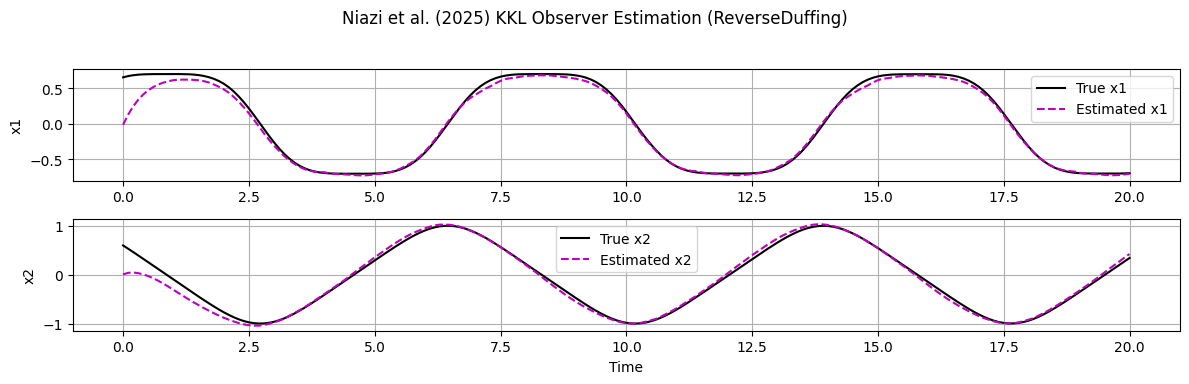

In [ ]:
print("\n--- Simulating Observer from SPINN Method ---")

# --- Create KKL Observer Instance for SPINN ---
kkl_observer_spinn = Observer(
    system=system,
    A_obs=A_obs_spinn,
    B_obs=B_obs_spinn,
    net=t_inv_net_spinn,  # Pass the trained inverse map (T_inv_net)
    t0=config_spinn['t_span'][0],
    tf=config_spinn['t_span'][1],
    N=int((config_spinn['t_span'][1] - config_spinn['t_span'][0]) / config_spinn['dt']),
    init_z_zero=True, # Start observer with z(0) = 0
    scaling_params=scaling_params_spinn
)

# --- Simulate and Plot Estimation Results ---
simulate_and_plot(kkl_observer_spinn, ic_test_torch, f"KKL Observer Estimation for {system.name} (SPINN Method))")

## Run AE (Buisson-Fenet et al. 2023)

In [ ]:
print("\n--- Training AE Method on Reverse Duffing Oscillator ---")

# --- KKL Observer Matrices for AE (Buisson-Fenet et al.) ---
# The observer matrices A and B are learnable in this method, so we pass initial ones
A_obs_ae_init, B_obs_ae_init = create_observer_matrices(n_z, n_y, system.name, strategy='diagonal')

# --- Training Configuration for AE ---
# Use common_config and extend/override with method-specific parameters
config_ae = common_config.copy()
config_ae.update({
    'epochs': common_config['epochs'],
    'lr': common_config['lr'],
    'nu': 1.0                     # Weight for PDE loss
})

# --- Train AE Method ---
start_time_ae = time.time()
model_dict_ae, scaling_params_ae = train_unsup_ae(
    system,
    A_obs_ae_init,
    B_obs_ae_init,
    config_ae
)
end_time_ae = time.time()
training_times['AE Method'] = end_time_ae - start_time_ae

# Extract trained learner
learner_ae = model_dict_ae['learner']
print("AE method training complete.")


--- Training AE Method on Reverse Duffing Oscillator ---
Using diagonal A and ones B for system ReverseDuffing with n_z=5, n_y=1.
Starting training for AE method on ReverseDuffing...
Generating data for training...


Generating Recon Trajectories:   0%|          | 0/100 [00:00<?, ?it/s]

Generated 20100 data points for reconstruction loss.
Generated 100000 data points for PDE loss.
Estimated z_min: tensor([-0.2555, -0.1815, -0.2423, -0.1800, -0.2376], device='cuda:0'), z_max: tensor([0.0317, 0.0890, 0.0279, 0.1092, 0.0069], device='cuda:0')


Epoch 1/15:   0%|          | 0/41 [00:00<?, ?it/s]


Epoch 1/15 - Total Loss: 0.997740, Recon Loss: 0.135146, PDE Loss: 0.862594


...


Epoch 13/15 - Total Loss: 0.001484, Recon Loss: 0.000085, PDE Loss: 0.001399


Epoch 14/15:   0%|          | 0/41 [00:00<?, ?it/s]


Epoch 14/15 - Total Loss: 0.001605, Recon Loss: 0.000306, PDE Loss: 0.001299
  Early stopping: Epochs with no improvement = 1


Epoch 15/15:   0%|          | 0/41 [00:00<?, ?it/s]


Epoch 15/15 - Total Loss: 0.001808, Recon Loss: 0.000545, PDE Loss: 0.001263
  Early stopping: Epochs with no improvement = 2
Training complete for AE method.
AE method training complete.



--- Simulating Observer from AE Method ---


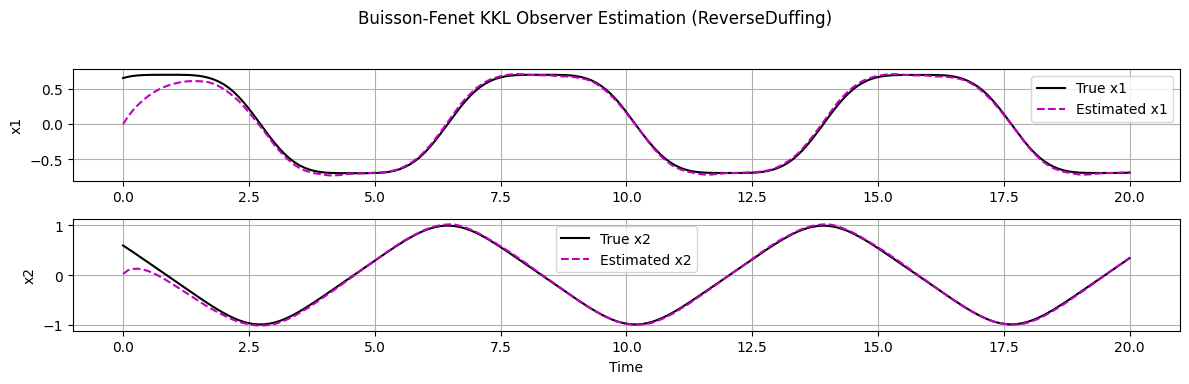

In [ ]:
print("\n--- Simulating Observer from AE Method ---")

# --- Create KKL Observer Instance for AE ---
kkl_observer_ae = Observer(
    system=system,
    A_obs=learner_ae.get_learned_observer_matrices()[0],
    B_obs=learner_ae.get_learned_observer_matrices()[1],
    net=learner_ae.t_inv_net,  # Pass the trained inverse map from the learner
    t0=config_ae['t_span'][0],
    tf=config_ae['t_span'][1],
    N=int((config_ae['t_span'][1] - config_ae['t_span'][0]) / config_ae['dt']),
    init_z_zero=True,  # Start observer with z(0) = 0
    scaling_params=scaling_params_ae
)

# --- Simulate and Plot Estimation Results ---
simulate_and_plot(kkl_observer_ae, ic_test_torch, f"KKL Observer Estimation for {system.name} (AE Method))")

## Run NODE (Miao & Gatsis 2023)

In [ ]:
print("\n--- Training NODE Method on Reverse Duffing Oscillator ---")

# --- Training Configuration for Miao & Gatsis et al. ---
# Use common_config and extend/override with method-specific parameters
config_node = common_config.copy()
config_node.update({
    'base_eig_init': -1.0,         # Initial value for observer eigenvalues
    'epochs': common_config['epochs'], # Ensure epochs is passed to this config
    'lr': common_config['lr'], # Ensure lr is passed to this config
})

A_obs_node, B_obs_node = create_observer_matrices(n_z, n_y, system.name, strategy='diagonal')

# F_matrix should correspond to the B matrix from a standard KKL observer form
F_matrix = B_obs_node.clone().detach()

# --- Train Miao & Gatsis Method ---
start_time_node = time.time()
model_dict_node, scaling_params_node = train_node_kkl(
    system,
    F_matrix,
    config_node
)
end_time_node = time.time()
training_times['NODE Method'] = end_time_node - start_time_node

print("NODE method training complete.")


--- Training NODE Method on Reverse Duffing Oscillator ---
Using diagonal A and ones B for system ReverseDuffing with n_z=5, n_y=1.
Starting training for Miao & Gatsis KKL method on ReverseDuffing...
Generating trajectory data for training...


Generating Trajectories:   0%|          | 0/100 [00:00<?, ?it/s]

Generated 100 trajectories of length 201.


Estimating Z bounds:   0%|          | 0/100 [00:00<?, ?it/s]

Scaling params estimated. z_range approx: tensor([2.2140, 2.2140, 2.2140, 2.2140, 2.2140], device='cuda:0')


...


Epoch 13/15 - Total Loss: 0.202443, Recon Loss: 0.202345, Reg Loss: 0.000098
  Learned Eigs (approx): min=-0.995, max=-0.987


NODE Method Epoch 14/15:   0%|          | 0/1 [00:00<?, ?it/s]


Epoch 14/15 - Total Loss: 0.204885, Recon Loss: 0.204787, Reg Loss: 0.000098
  Learned Eigs (approx): min=-0.994, max=-0.986
  Early stopping: Epochs with no improvement = 1


NODE Method Epoch 15/15:   0%|          | 0/1 [00:00<?, ?it/s]


Epoch 15/15 - Total Loss: 0.209614, Recon Loss: 0.209516, Reg Loss: 0.000098
  Learned Eigs (approx): min=-0.994, max=-0.985
  Early stopping: Epochs with no improvement = 2
Training complete for NODE method.
NODE method training complete.



--- Simulating Miao & Gatsis (2023) Observer ---


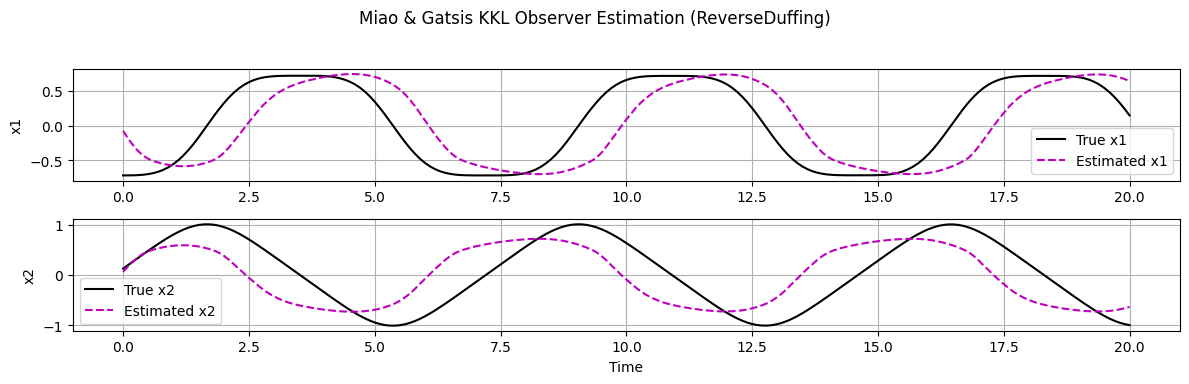

In [ ]:
print("\n--- Simulating Observer from NODE Method ---")
# --- 4. Create KKL Observer Instance for NODE ---
learner_node = model_dict_node['learner']
kkl_observer_node = MiaoGatsis_KKL_Observer(
    learner=learner_node,
    system=system,
    t0=config_node['t_span'][0],
    tf=config_node['t_span'][1],
    N=int((config_node['t_span'][1] - config_node['t_span'][0]) / config_node['dt']),
    init_z_zero=True,
    scaling_params=scaling_params_node
)

# Define a test initial condition for the true system from the same hypercube as training
test_x_space_bounds = system.x_space_bounds
ic_test_np = sample_x0(test_x_space_bounds, n_samples=1) # Sample one test initial condition
ic_test_torch = torch.tensor(ic_test_np, dtype=torch.float32).unsqueeze(0).to(device) # Add batch dim and move to device

# --- Simulate and Plot Estimation Results ---
simulate_and_plot(kkl_observer_node, ic_test_torch, f"KKL Observer Estimation for {system.name} (NODE Method))")

## Run DMF (Peralez & Nadri 2024)

In [ ]:
print("\n--- Training DMF Method on Reverse Duffing Oscillator ---")

# --- KKL Observer Matrices for DMF ---
# The observer matrices A and B are learnable in this method, so we pass initial ones
A_obs_dmf_init, B_obs_dmf_init = create_observer_matrices(n_z, n_y, system.name, strategy='diagonal')

# --- Training Configuration for Peralez & Nadri et al. ---
# Use common_config and extend/override with method-specific parameters
config_dmf = common_config.copy()
config_dmf.update({
    'nu_recon': 1.0,               # Weight for reconstruction loss
    'nu_pde': 1.0,                 # Weight for PDE loss
    'nu_reg': 1e-5,                # Weight for regularization loss
})

# --- Train Peralez & Nadri Method ---
start_time_dmf = time.time()
model_dict_dmf, scaling_params_dmf = train_dmf(
    system,
    config_dmf
)
end_time_dmf = time.time()
training_times['DMF Method'] = end_time_dmf - start_time_dmf

# Extract trained learner
learner_dmf = model_dict_dmf['learner']
print("DMF method training complete.")


--- Training DMF Method on Reverse Duffing Oscillator ---
Using diagonal A and ones B for system ReverseDuffing with n_z=5, n_y=1.
Starting training for DMF method on ReverseDuffing...
Using diagonal A and ones B for system ReverseDuffing with n_z=5, n_y=1.
Generating data for training...


Generating Recon Trajectories:   0%|          | 0/100 [00:00<?, ?it/s]

Generated 20100 data points for reconstruction loss.
Generated 100000 data points for PDE loss.
Estimated z_min: tensor([-0.0859, -0.0465, -0.0673, -0.1459, -0.1649], device='cuda:0'), z_max: tensor([0.1494, 0.1987, 0.2038, 0.1362, 0.0992], device='cuda:0')


Epoch 1/15:   0%|          | 0/41 [00:00<?, ?it/s]


Epoch 1/15 - Total Loss: 0.862550, Recon Loss: 0.124581, PDE Loss: 0.737956, Reg Loss: 1.338719


...


Epoch 13/15 - Total Loss: 0.001670, Recon Loss: 0.000119, PDE Loss: 0.001538, Reg Loss: 1.311699


Epoch 14/15:   0%|          | 0/41 [00:00<?, ?it/s]


Epoch 14/15 - Total Loss: 0.001555, Recon Loss: 0.000140, PDE Loss: 0.001402, Reg Loss: 1.311642


Epoch 15/15:   0%|          | 0/41 [00:00<?, ?it/s]


Epoch 15/15 - Total Loss: 0.001638, Recon Loss: 0.000266, PDE Loss: 0.001359, Reg Loss: 1.311587
  Early stopping: Epochs with no improvement = 1
Training complete for DMF method.
DMF method training complete.



--- Simulating Peralez & Nadri (2024) Observer ---


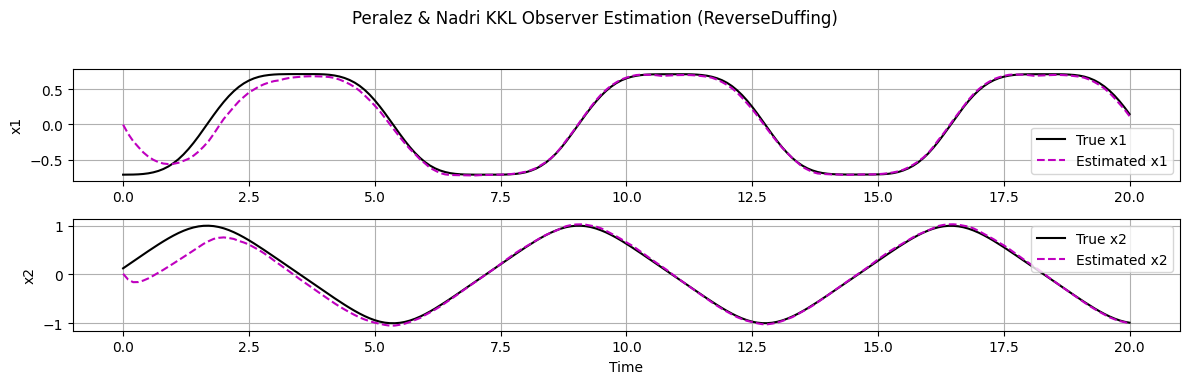

In [ ]:
print("\n--- Simulating Observer from DMF Method ---")

# --- Create KKL Observer Instance for DMF ---
kkl_observer_dmf = PeralezNadriObserver(
    learner=learner_dmf,
    system=system,
    t0=config_dmf['t_span'][0],
    tf=config_dmf['t_span'][1],
    N=int((config_dmf['t_span'][1] - config_dmf['t_span'][0]) / config_dmf['dt']),
    init_z_zero=True,
    scaling_params=scaling_params_dmf
)

# --- Simulate and Plot Estimation Results ---
simulate_and_plot(kkl_observer_dmf, ic_test_torch, f"KKL Observer Estimation for {system.name} (DMF Method))")

## Computation Times

In [ ]:
print(training_times)

{'SPINN Method': 73.6194281578064, 'AE Method': 19.676402807235718, 'NODE Method': 2343.4196677207947, 'DMF Method': 19.049635887145996}


## Comparison Plot Results

Simulate the true system state trajectory, then for each trained observer, simulate its estimation. Plot the true state trajectories and the estimated state trajectories from all four methods.



--- Plotting Results for All Methods ---
Simulating SPINN observer...
Simulating AE observer...
Simulating NODE observer...
Simulating DMF observer...


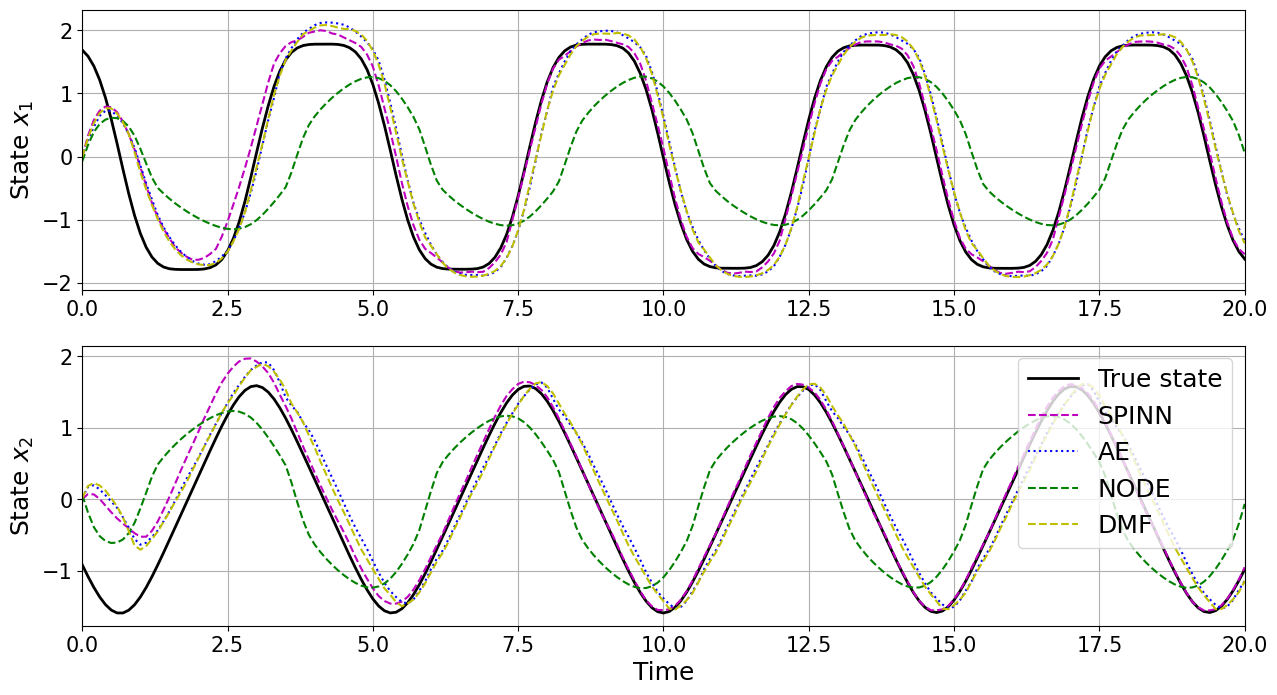

In [ ]:
print("\n--- Plotting Results for All Methods ---")

# 1. Simulate the true system trajectory
t_span = config_spinn['t_span'] # Use t_span from any config, they are all the same
dt = config_spinn['dt']
t_eval_np = np.arange(t_span[0], t_span[1] + dt, dt)

# Generate a NEW random initial condition
# ic_test_np = sample_x0(system.x_space_bounds, n_samples=1) # Sample one test initial condition
test_x_space_bounds = [(-3, 3), (-3, 3)]
ic_test_np = sample_x0(test_x_space_bounds, n_samples=1)
ic_test_torch = torch.tensor(ic_test_np, dtype=torch.float32).unsqueeze(0).to(device) # Add batch dim and move to device

sol = solve_ivp(system.f, t_span, ic_test_np.flatten(), t_eval=t_eval_np, method='RK45')
t_eval_true_np = sol.t
x_true_np = sol.y.T # Shape (N+1, n_x)
y_true_torch = torch.tensor(system.h(x_true_np), dtype=torch.float32).to(device) # True y for observers


# 2. Create a list to store estimated trajectories
all_estimated_trajectories = []

# 3. Create a list of tuples (observer_instance, method_name)
kkl_observer_spinn = Observer(
    system=system,
    A_obs=A_obs_spinn,
    B_obs=B_obs_spinn,
    net=t_inv_net_spinn,  # Pass the trained inverse map (T_inv_net)
    t0=config_spinn['t_span'][0],
    tf=config_spinn['t_span'][1],
    N=int((config_spinn['t_span'][1] - config_spinn['t_span'][0]) / config_spinn['dt']),
    init_z_zero=True, # Start observer with z(0) = 0
    scaling_params=scaling_params_spinn
)

kkl_observer_ae = Observer(
    system=system,
    A_obs=learner_ae.get_learned_observer_matrices()[0],
    B_obs=learner_ae.get_learned_observer_matrices()[1],
    net=learner_ae.t_inv_net,  # Pass the trained inverse map from the learner
    t0=config_ae['t_span'][0],
    tf=config_ae['t_span'][1],
    N=int((config_ae['t_span'][1] - config_ae['t_span'][0]) / config_ae['dt']),
    init_z_zero=True,  # Start observer with z(0) = 0
    scaling_params=scaling_params_ae
)

kkl_observer_node = MiaoGatsis_KKL_Observer(
    learner=learner_node,
    system=system,
    t0=config_node['t_span'][0],
    tf=config_node['t_span'][1],
    N=int((config_node['t_span'][1] - config_node['t_span'][0]) / config_node['dt']),
    init_z_zero=True,
    scaling_params=scaling_params_node
)

kkl_observer_dmf = PeralezNadriObserver(
    learner=learner_dmf,
    system=system,
    t0=config_dmf['t_span'][0],
    tf=config_dmf['t_span'][1],
    N=int((config_dmf['t_span'][1] - config_dmf['t_span'][0]) / config_dmf['dt']),
    init_z_zero=True,
    scaling_params=scaling_params_dmf
)

observers_to_compare = [
    (kkl_observer_spinn, 'SPINN'),
    (kkl_observer_ae, 'AE'),
    (kkl_observer_node, 'NODE'),
    (kkl_observer_dmf, 'DMF')
]

# 4. For each observer, simulate its estimation and store the results
for observer_instance, method_name in observers_to_compare:
    print(f"Simulating {method_name} observer...")
    _, x_hat_traj_unscaled = observer_instance.simulate(observer_instance.t_eval_torch, y_true_torch)
    all_estimated_trajectories.append((x_hat_traj_unscaled.cpu().detach().numpy(), method_name))

# 5. Create a Matplotlib figure with system.n_x subplots
plt.figure(figsize=(15, 4 * system.n_x))

colors = ['m--', 'b:', 'g--', 'y--'] # Different line styles and colors for each method

for i in range(system.n_x):
    plt.subplot(system.n_x, 1, i + 1)

    # Plot true state
    plt.plot(t_eval_true_np, x_true_np[:, i], 'k-', linewidth=2, label=f'True state')

    # Plot estimated states from each method
    for j, (estimated_traj, method_name) in enumerate(all_estimated_trajectories):
        plt.plot(t_eval_true_np, estimated_traj[:, i], colors[j], label=f'{method_name}')

    plt.ylabel(f'State $x_{i+1}$', fontsize=18)
    plt.grid(True)
    if i == system.n_x - 1:  # Add legend only to the last subplot
        plt.legend(loc='upper right', fontsize=18)
    plt.xlim(t_eval_true_np[0], 20) # Set x-axis limit
    plt.tick_params(axis='x', labelsize=15)
    plt.tick_params(axis='y', labelsize=15)

plt.xlabel('Time', fontsize=18)

plt.show()

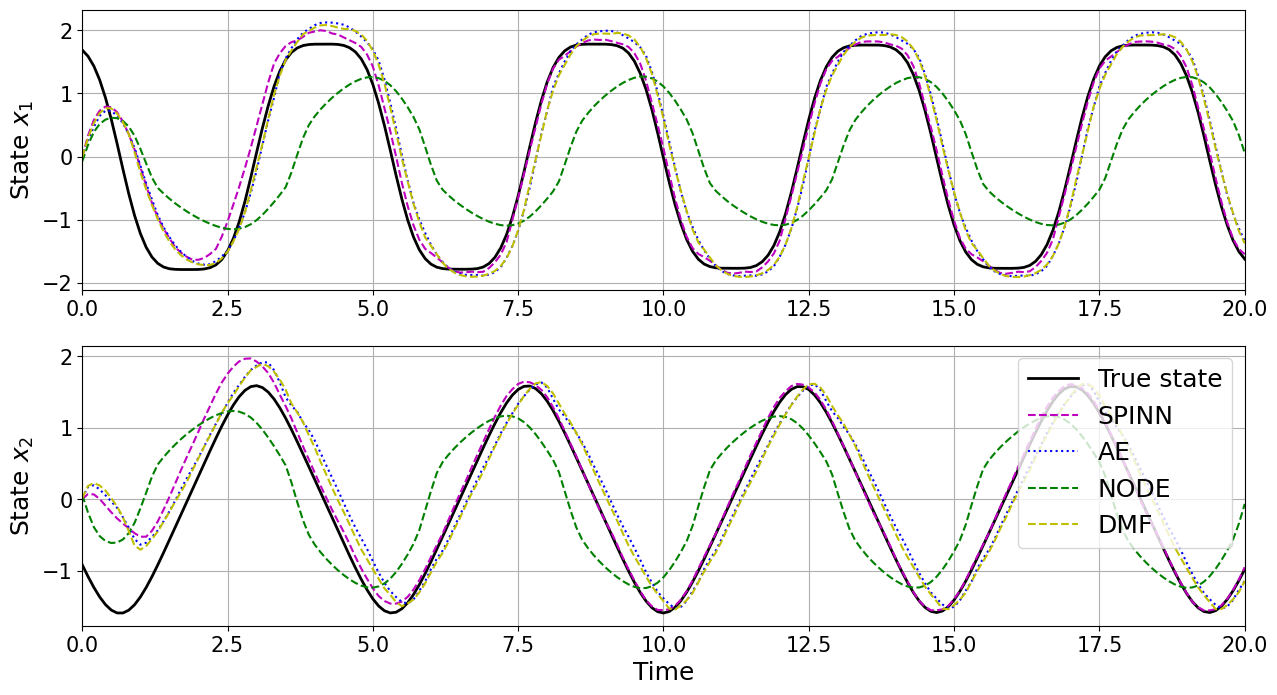

In [ ]:
# 5. Create a Matplotlib figure with system.n_x subplots
plt.figure(figsize=(15, 4 * system.n_x))

colors = ['m--', 'b:', 'g--', 'y--'] # Different line styles and colors for each method

for i in range(system.n_x):
    plt.subplot(system.n_x, 1, i + 1)

    # Plot true state
    plt.plot(t_eval_true_np, x_true_np[:, i], 'k-', linewidth=2, label=f'True state')

    # Plot estimated states from each method
    for j, (estimated_traj, method_name) in enumerate(all_estimated_trajectories):
        plt.plot(t_eval_true_np, estimated_traj[:, i], colors[j], label=f'{method_name}')

    plt.ylabel(f'State $x_{i+1}$', fontsize=18)
    plt.grid(True)
    if i == system.n_x - 1:  # Add legend only to the last subplot
        plt.legend(loc='upper right', fontsize=18)
    plt.xlim(t_eval_true_np[0], 20) # Set x-axis limit
    plt.tick_params(axis='x', labelsize=15)
    plt.tick_params(axis='y', labelsize=15)

plt.xlabel('Time', fontsize=18)

# Save the figure as a PNG file
plt.savefig('kkl_observer_comparison.png', bbox_inches='tight')

plt.show()
plt.close() # Close the figure to free up memory

## Test Trials (100)

Iterate multiple times. In each iteration, generate a new random initial condition, simulate the true system, then simulate each of the four trained observers. For each observer's estimation, calculate the RMSE and SMAPE against the true trajectory and store these metrics.


In [ ]:
# Implements Python functions to calculate Root Mean Square Error (RMSE)
# and Symmetric Mean Absolute Percentage Error (SMAPE)
# between true and estimated trajectories.

import numpy as np

def calculate_rmse(true_traj, estimated_traj):
    """
    Calculates the Root Mean Square Error (RMSE) between true and estimated trajectories.

    Args:
        true_traj (np.ndarray): The true trajectory array.
        estimated_traj (np.ndarray): The estimated trajectory array.

    Returns:
        float: The RMSE value.
    """
    # Compute the squared difference
    squared_diff = (true_traj - estimated_traj)**2
    # Calculate the mean of squared differences
    mean_squared_diff = np.mean(squared_diff)
    # Return the square root of the mean
    rmse = np.sqrt(mean_squared_diff)
    return rmse

def calculate_smape(true_traj, estimated_traj):
    """
    Calculates the Symmetric Mean Absolute Percentage Error (SMAPE) between true and estimated trajectories.
    Handles potential division by zero.

    Args:
        true_traj (np.ndarray): The true trajectory array.
        estimated_traj (np.ndarray): The estimated trajectory array.

    Returns:
        float: The SMAPE percentage value.
    """
    numerator = np.abs(estimated_traj - true_traj)
    denominator = np.abs(true_traj) + np.abs(estimated_traj)

    # Handle potential division by zero
    # If denominator is 0, and numerator is also 0, the term should be 0. Otherwise, it's NaN or inf.
    # np.divide handles 0/0 as NaN, and x/0 as inf. np.nan_to_num converts NaN to 0 and inf to large finite numbers.
    # For SMAPE, 0/0 is 0.
    smape_terms = np.divide(numerator, denominator, out=np.zeros_like(numerator, dtype=float), where=denominator!=0)

    smape = np.mean(smape_terms) * 100
    return smape

print("RMSE and SMAPE functions defined.")

RMSE and SMAPE functions defined.



--- Running 100 comparison runs ---


Comparison Runs:   0%|          | 0/100 [00:00<?, ?it/s]


All comparison runs finished and metrics have been collected.


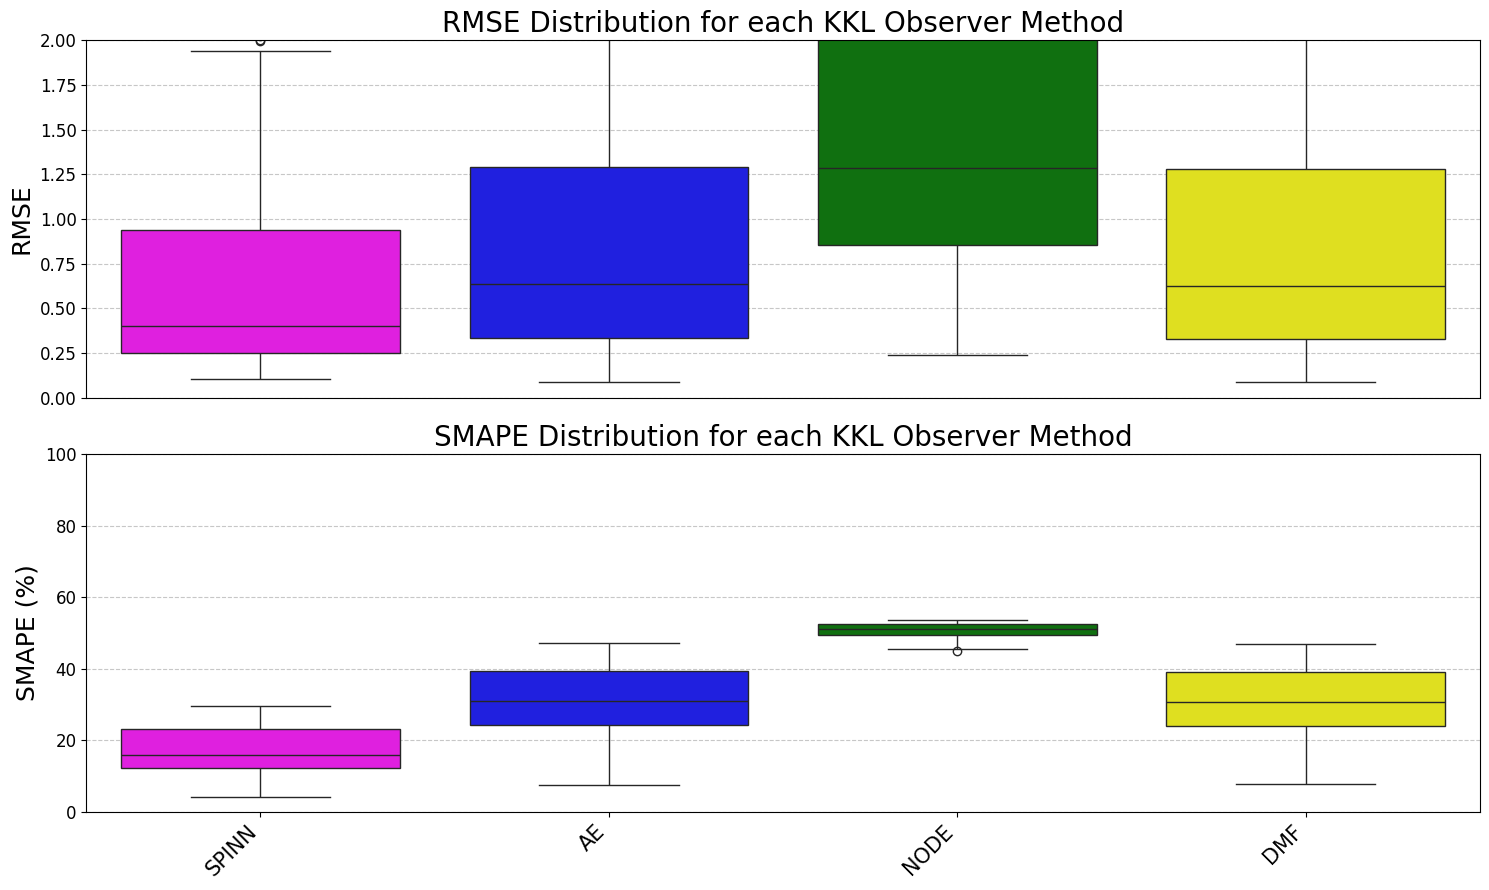

In [ ]:
import collections
import matplotlib.pyplot as plt
import seaborn as sns

# 1. Initialize an empty dictionary to store metrics
metrics_data = collections.defaultdict(lambda: collections.defaultdict(list))

# 2. Set the number of iterations for the comparison loop
num_comparison_runs = 100

# 3. Start a loop for num_comparison_runs iterations
print(f"\n--- Running {num_comparison_runs} comparison runs ---")
for run in tqdm(range(num_comparison_runs), desc="Comparison Runs"):
    # 4.a. Generate a new random initial condition
    # Update test_x_space_bounds to [-2, 2] for both dimensions
    test_x_space_bounds = [(-3, 3), (-3, 3)]
    ic_test_np = sample_x0(test_x_space_bounds, n_samples=1)
    # 4.b. Convert to PyTorch tensor and move to device
    ic_test_torch = torch.tensor(ic_test_np, dtype=torch.float32).unsqueeze(0).to(device)

    # Use t_span and dt from a common config (e.g., config_spinn)
    t_span = config_spinn['t_span']
    dt = config_spinn['dt']
    t_eval_np = np.arange(t_span[0], t_span[1] + dt, dt)

    # 4.c. Simulate the true system's trajectory
    sol = solve_ivp(system.f, t_span, ic_test_np.flatten(), t_eval=t_eval_np, method='RK45')
    x_true_np = sol.y.T # Shape (N+1, n_x)
    y_true_torch = torch.tensor(system.h(x_true_np), dtype=torch.float32).to(device) # True y for observers

    # 4.d. For each of the four observer instances:
    for observer_instance, method_name in observers_to_compare:
        # i. Simulate the observer
        _, x_hat_traj_unscaled = observer_instance.simulate(observer_instance.t_eval_torch, y_true_torch)
        # ii. Convert to NumPy array
        x_hat_np = x_hat_traj_unscaled.cpu().detach().numpy()

        # iii. Calculate RMSE and SMAPE
        rmse = calculate_rmse(x_true_np, x_hat_np)
        smape = calculate_smape(x_true_np, x_hat_np)

        # iv. Store the calculated metrics
        metrics_data[method_name]['RMSE'].append(rmse)
        metrics_data[method_name]['SMAPE'].append(smape)

# 5. After the loop, print a message
print("\nAll comparison runs finished and metrics have been collected.")


# 6. Plot RMSE and SMAPE

# Prepare data for plotting
rmse_data = {method: metrics_data[method]['RMSE'] for method in metrics_data}
smape_data = {method: metrics_data[method]['SMAPE'] for method in metrics_data}

method_names = list(metrics_data.keys())

# Create a single figure with two subplots
fig, ax = plt.subplots(2, 1, figsize=(15, 10))

# Plot RMSE on the first subplot
sns.boxplot(data=list(rmse_data.values()), palette=['magenta', 'blue', 'green', 'yellow'], ax=ax[0])
ax[0].set_title('RMSE Distribution for each KKL Observer Method', fontsize=20)
ax[0].set_ylabel('RMSE', fontsize=18)
ax[0].grid(axis='y', linestyle='--', alpha=0.7)
ax[0].set_xticks(ticks=[])
ax[0].tick_params(axis='y', labelsize=12)
# ax[0].set_ylim(0,4)

# Plot SMAPE on the second subplot
sns.boxplot(data=list(smape_data.values()), palette=['magenta', 'blue', 'green', 'yellow'], ax=ax[1])
ax[1].set_title('SMAPE Distribution for each KKL Observer Method', fontsize=20)
ax[1].set_ylabel('SMAPE (%)', fontsize=18)
ax[1].grid(axis='y', linestyle='--', alpha=0.7)
ax[1].set_xticks(ticks=range(len(method_names)), labels=method_names, rotation=45, ha='right', fontsize=15)
ax[1].tick_params(axis='y', labelsize=12)
# ax[1].set_ylim(0,70)

plt.tight_layout(rect=[0, 0.05, 1, 0.95])

plt.show()


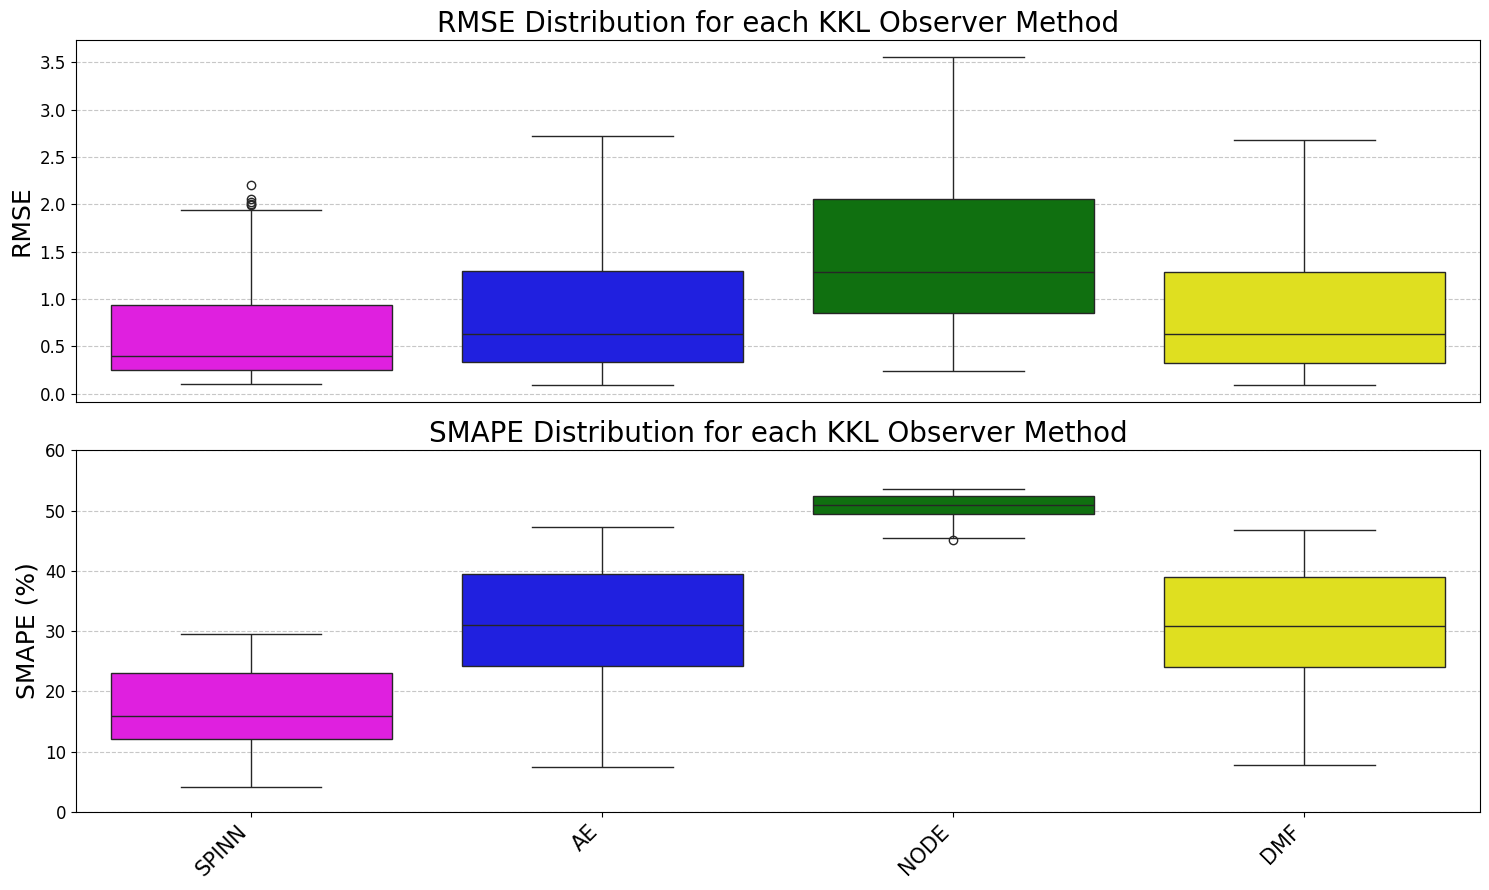

In [ ]:
# 6. Plot RMSE and SMAPE

# Prepare data for plotting
rmse_data = {method: metrics_data[method]['RMSE'] for method in metrics_data}
smape_data = {method: metrics_data[method]['SMAPE'] for method in metrics_data}

method_names = list(metrics_data.keys())

# Create a single figure with two subplots
fig, ax = plt.subplots(2, 1, figsize=(15, 10))

# Plot RMSE on the first subplot
sns.boxplot(data=list(rmse_data.values()), palette=['magenta', 'blue', 'green', 'yellow'], ax=ax[0])
ax[0].set_title('RMSE Distribution for each KKL Observer Method', fontsize=20)
ax[0].set_ylabel('RMSE', fontsize=18)
ax[0].grid(axis='y', linestyle='--', alpha=0.7)
ax[0].set_xticks(ticks=[])
ax[0].tick_params(axis='y', labelsize=12)
# ax[0].set_ylim(0,4)

# Plot SMAPE on the second subplot
sns.boxplot(data=list(smape_data.values()), palette=['magenta', 'blue', 'green', 'yellow'], ax=ax[1])
ax[1].set_title('SMAPE Distribution for each KKL Observer Method', fontsize=20)
ax[1].set_ylabel('SMAPE (%)', fontsize=18)
ax[1].grid(axis='y', linestyle='--', alpha=0.7)
ax[1].set_xticks(ticks=range(len(method_names)), labels=method_names, rotation=45, ha='right', fontsize=15)
ax[1].tick_params(axis='y', labelsize=12)
ax[1].set_ylim(0,60)

plt.tight_layout(rect=[0, 0.05, 1, 0.95])

# Save the combined figure
plt.savefig('kkl_observer_metrics_comparison.png', bbox_inches='tight')
plt.show()
plt.close()
